# NB10 — Evaluación detallada de las 84 corridas

## Propósito

Sobre las predicciones OOF y test ya guardadas en `Outputs/Predicciones_v2/`, calcular para cada combinación (configuración × cabeza):

- **AUC** con IC 95% por bootstrap (1.000 remuestreos)
- **Average Precision** (PR-AUC) con IC 95% — métrica complementaria con desbalance
- **Brier score** — métrica conjunta de discriminación y calibración
- **ECE** (Expected Calibration Error) — calibración pura

Y, sobre los resultados, ejecutar los análisis críticos:

1. **Comparaciones pareadas DeLong** entre configuraciones top (¿GAP+GMP supera a pool 2×2? ¿A+B mejora a A?).
2. **Análisis estratificado por densidad mamaria** (A/B/C/D) sobre el hold-out — cierra una limitación declarada del Hito 2.
3. **Comparación cuantitativa contra Hito 2** (NB05/NB07) con DeLong sobre el mismo test pool.
4. **Análisis post-hoc M→E**: agregar predicciones de mama a estudio con `max(pred_L, pred_R)` y comparar con E_A directo.
5. **Curvas ROC y PR** de las top configuraciones.

## Salida

- `Outputs/Predicciones_v2/eval_completo_v2.csv` — tabla maestra con todas las métricas.
- `Outputs/Predicciones_v2/delong_pareado_v2.csv` — todas las comparaciones DeLong.
- `Outputs/Predicciones_v2/eval_densidad_v2.csv` — AUC por estrato de densidad.
- `Outputs/Predicciones_v2/curvas_top.png` — curvas ROC y PR de las 5 mejores configuraciones.

In [1]:
import os, sys, glob, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, roc_curve, precision_recall_curve

# Raíz del proyecto: por defecto, la carpeta padre de notebooks/.
# Sobrescribible con la variable de entorno TFM_PROJECT_ROOT.
BASE      = os.environ.get('TFM_PROJECT_ROOT',
                           os.path.abspath(os.path.join(os.getcwd(), '..')))
OUTPUTS      = os.path.join(BASE, 'outputs')
FEATURES_DIR = os.path.join(OUTPUTS, 'Features')
PRED_DIR_V2  = os.path.join(OUTPUTS, 'Predicciones_v2')
PRED_DIR_V1  = os.path.join(OUTPUTS, 'Predicciones')      # Hito 2
NB_DIR    = os.path.join(BASE, 'src')

sys.path.insert(0, NB_DIR)
from tfm_eval import (  # noqa: E402
    bootstrap_metric_ci, ece_score, delong_test,
    aggregate_breast_to_study, compute_full_metrics, SEED,
)

np.random.seed(SEED)
print(f'PRED_DIR_V2: {PRED_DIR_V2}')
print(f'PRED_DIR_V1 (Hito 2): {PRED_DIR_V1}')

PRED_DIR_V2: c:\Users\victo\Documents\TFM\Proyecto\outputs\Predicciones_v2
PRED_DIR_V1 (Hito 2): c:\Users\victo\Documents\TFM\Proyecto\outputs\Predicciones


## 1. Cargar metadata y etiquetas

Replicamos la misma lógica de construcción de y/splits que en NB09 para garantizar alineación con las predicciones.

In [2]:
meta = pd.read_csv(os.path.join(FEATURES_DIR, 'metadata.csv'))
N = len(meta)
print(f'N estudios: {N}')

# Nivel estudio
y_E = meta['y_estudio'].values.astype(int)
split_E = meta['split'].values
is_train_E = (split_E == 'training')
is_test_E  = (split_E == 'test')
density_E  = meta['density'].values
study_ids_E = meta['study_id'].values

# Nivel mama: replicar L y R EN EL MISMO ORDEN que el NB09 construyó
y_M = np.concatenate([meta['y_L'].values, meta['y_R'].values]).astype(int)
split_M = np.concatenate([meta['split'].values, meta['split'].values])
is_train_M = (split_M == 'training')
is_test_M  = (split_M == 'test')
density_M  = np.concatenate([meta['density_L'].values, meta['density_R'].values])
study_ids_M = np.concatenate([meta['study_id'].values, meta['study_id'].values])

print(f'Nivel estudio: train={is_train_E.sum()} (pos={int(y_E[is_train_E].sum())})  '
      f'test={is_test_E.sum()} (pos={int(y_E[is_test_E].sum())})')
print(f'Nivel mama:    train={is_train_M.sum()} (pos={int(y_M[is_train_M].sum())})  '
      f'test={is_test_M.sum()} (pos={int(y_M[is_test_M].sum())})')

# Para evaluar test:
y_E_test = y_E[is_test_E]
y_M_test = y_M[is_test_M]
density_E_test = density_E[is_test_E]
density_M_test = density_M[is_test_M]
study_ids_E_test = study_ids_E[is_test_E]

# Para OOF, las etiquetas son las del training pool
y_E_oof = y_E[is_train_E]
y_M_oof = y_M[is_train_M]

# ─────────────────────────────────────────────────────────────────────
# EDAD y BI-RADS ORIGINAL — necesarios para análisis estratificados
# (ambos añadidos a raíz del feedback de la tutora, Hito 3)
# ─────────────────────────────────────────────────────────────────────
import re

# 1) Edad: se extrae del DICOM metadata (Patient's Age formato "053Y")
DICOM_META_CSV = os.path.join(BASE, 'Data', 'vindr-mammo', 'metadata.csv')
if os.path.exists(DICOM_META_CSV):
    dcm_meta = pd.read_csv(DICOM_META_CSV).rename(columns={'SOP Instance UID.1': 'image_id'})
    def _parse_age(s):
        if pd.isna(s): return np.nan
        m = re.match(r'^0*(\d+)Y$', str(s))
        return float(m.group(1)) if m else np.nan
    dcm_meta['age'] = dcm_meta["Patient's Age"].apply(_parse_age)

    # BI-RADS original 1-5 desde breast-level (nivel vista → agregado a mama y estudio)
    BREAST_CSV = os.path.join(BASE, 'Data', 'vindr-mammo', 'breast-level_annotations.csv')
    breast_ann = pd.read_csv(BREAST_CSV)
    breast_ann['birads_num'] = breast_ann['breast_birads'].str.replace('BI-RADS ', '').astype(int)

    # Edad por estudio: constante entre vistas
    age_per_study = breast_ann.merge(dcm_meta[['image_id', 'age']], on='image_id', how='left') \
                              .groupby('study_id')['age'].first().reset_index()

    # BI-RADS por estudio: máximo de las 4 vistas
    estudio_birads = breast_ann.groupby('study_id').agg(birads_orig=('birads_num', 'max')).reset_index()

    # BI-RADS por mama: máximo de las 2 vistas de esa mama
    mama_birads = breast_ann.groupby(['study_id', 'laterality']).agg(birads_orig=('birads_num', 'max')).reset_index()

    # Merge en el orden de meta (done_studies)
    meta_ext = meta[['study_id']].merge(age_per_study, on='study_id', how='left') \
                                 .merge(estudio_birads, on='study_id', how='left')
    age_E = meta_ext['age'].values
    birads_E_orig = meta_ext['birads_orig'].values

    # A nivel mama: L y R en el orden [todos L, todos R]
    mama_L = meta[['study_id']].merge(mama_birads[mama_birads.laterality=='L'][['study_id', 'birads_orig']], on='study_id', how='left')
    mama_R = meta[['study_id']].merge(mama_birads[mama_birads.laterality=='R'][['study_id', 'birads_orig']], on='study_id', how='left')
    birads_M_orig = np.concatenate([mama_L['birads_orig'].values, mama_R['birads_orig'].values])
    age_M = np.concatenate([age_E, age_E])   # misma edad para L y R (paciente)

    # Extraer subset test
    age_E_test = age_E[is_test_E]
    age_M_test = age_M[is_test_M]
    birads_E_orig_test = birads_E_orig[is_test_E]
    birads_M_orig_test = birads_M_orig[is_test_M]

    # Bins de edad (con extremos filtrados: se descartan edad<20 o >90)
    _AGE_BINS = [20, 40, 50, 60, 70, 90]
    _AGE_LABELS = ['20-39', '40-49', '50-59', '60-69', '70+']
    age_bin_E_test = pd.cut(age_E_test, bins=_AGE_BINS, labels=_AGE_LABELS, right=False)
    age_bin_M_test = pd.cut(age_M_test, bins=_AGE_BINS, labels=_AGE_LABELS, right=False)

    print(f'\nEdad — estudios test con edad válida: {(~pd.isna(age_bin_E_test)).sum()}/{len(age_E_test)}')
    print(f'Edad — mamas test con edad válida:    {(~pd.isna(age_bin_M_test)).sum()}/{len(age_M_test)}')
    print(f'BI-RADS original (nivel estudio test): {pd.Series(birads_E_orig_test).value_counts().sort_index().to_dict()}')
    print(f'BI-RADS original (nivel mama test):    {pd.Series(birads_M_orig_test).value_counts().sort_index().to_dict()}')
    HAS_EXTRA_ANNS = True
else:
    print('Aviso: DICOM metadata no encontrado — análisis por edad y BI-RADS original quedarán deshabilitados.')
    HAS_EXTRA_ANNS = False


N estudios: 4999
Nivel estudio: train=3999 (pos=385)  test=1000 (pos=96)
Nivel mama:    train=7998 (pos=395)  test=2000 (pos=99)

Edad — estudios test con edad válida: 869/1000
Edad — mamas test con edad válida:    1738/2000
BI-RADS original (nivel estudio test): {1: 494, 2: 319, 3: 91, 4: 73, 5: 23}
BI-RADS original (nivel mama test):    {1: 1341, 2: 467, 3: 93, 4: 76, 5: 23}


## 2. Funciones para cargar predicciones y métricas

Cada corrida está en disco como dos arrays:
- `{config}__{head}_oof.npy` — predicciones OOF sobre el training pool
- `{config}__{head}_test.npy` — predicciones ensemble sobre el test pool

In [3]:
def load_predictions(config, head, source='v2'):
    """Carga (oof, test) para una combinación config-head."""
    pdir = PRED_DIR_V2 if source == 'v2' else PRED_DIR_V1
    oof  = np.load(os.path.join(pdir, f'{config}__{head}_oof.npy'))
    test = np.load(os.path.join(pdir, f'{config}__{head}_test.npy'))
    return oof, test

def get_level(config):
    return 'estudio' if config.startswith('E_') else 'mama'

def get_y_test(config):
    return y_E_test if config.startswith('E_') else y_M_test

def get_y_oof(config):
    return y_E_oof if config.startswith('E_') else y_M_oof

# Listado de todas las corridas v2 (a partir del resumen, no del filesystem para mantener orden)
resumen = pd.read_csv(os.path.join(PRED_DIR_V2, 'resumen_v2.csv'))
runs_v2 = list(zip(resumen['config'], resumen['head']))
print(f'Corridas a evaluar: {len(runs_v2)}')

Corridas a evaluar: 84


## 3. Tabla maestra: métricas completas para las 84 corridas (test)

Para cada corrida calcula AUC + IC95%, AP + IC95%, Brier y ECE sobre el test pool. Bootstrap con n=1000 remuestreos. Tarda aproximadamente 5-10 minutos en total.

In [4]:
rows = []
t0 = time.time()
for i, (config, head) in enumerate(runs_v2, start=1):
    try:
        _, test_pred = load_predictions(config, head)
    except FileNotFoundError as e:
        print(f'  [{i}/{len(runs_v2)}] {config}__{head}  FALTA  ({e})')
        continue
    y_test = get_y_test(config)
    if len(test_pred) != len(y_test):
        print(f'  [{i}/{len(runs_v2)}] {config}__{head}  TAMAÑO INCORRECTO ({len(test_pred)} vs {len(y_test)})')
        continue
    
    metrics = compute_full_metrics(y_test, test_pred, n_boot=1000)
    rows.append({
        'config': config, 'head': head, 'level': get_level(config),
        **metrics,
    })
    if i % 10 == 0:
        print(f'  [{i}/{len(runs_v2)}] {config}__{head}  AUC={metrics["auc"]:.4f}  ({time.time()-t0:.1f}s)')

df_eval = pd.DataFrame(rows).sort_values('auc', ascending=False).reset_index(drop=True)
df_eval.to_csv(os.path.join(PRED_DIR_V2, 'eval_completo_v2.csv'), index=False)
print(f'\nGuardado: eval_completo_v2.csv  ({time.time()-t0:.1f}s)')

  [10/84] M_A_gg__rf  AUC=0.6661  (13.4s)
  [20/84] M_AB_22__rf  AUC=0.6458  (26.1s)
  [30/84] M_AB_22__mlp  AUC=0.6386  (38.6s)
  [40/84] E_A_gg__extratrees  AUC=0.6318  (50.8s)
  [50/84] E_AB_22__histgb  AUC=0.6247  (61.7s)
  [60/84] E_B_gg__xgb  AUC=0.6139  (73.8s)
  [70/84] E_B_22__extratrees  AUC=0.6058  (85.2s)
  [80/84] E_A_22__logreg_l2  AUC=0.5828  (96.2s)

Guardado: eval_completo_v2.csv  (100.6s)


In [5]:
# TOP 15 con todas las métricas
print('TOP 15 por AUC test (con IC 95%, AP, Brier, ECE):')
print()
top = df_eval.head(15)
for _, r in top.iterrows():
    print(f"  {r['config']:14s} {r['head']:12s}  "
          f"AUC={r['auc']:.4f} [{r['auc_lo']:.4f}, {r['auc_hi']:.4f}]   "
          f"AP={r['ap']:.4f}   Brier={r['brier']:.4f}   ECE={r['ece']:.4f}")

TOP 15 por AUC test (con IC 95%, AP, Brier, ECE):

  M_A_gg         mlp           AUC=0.6866 [0.6289, 0.7417]   AP=0.2422   Brier=0.1943   ECE=0.3811
  M_A_22         xgb           AUC=0.6813 [0.6181, 0.7440]   AP=0.3036   Brier=0.1175   ECE=0.2755
  M_AB_gg        histgb        AUC=0.6811 [0.6189, 0.7412]   AP=0.2915   Brier=0.0649   ECE=0.1468
  M_A_22         rf            AUC=0.6803 [0.6210, 0.7374]   AP=0.2847   Brier=0.0407   ECE=0.0107
  M_A_gg         logreg_en     AUC=0.6763 [0.6165, 0.7371]   AP=0.2251   Brier=0.1531   ECE=0.2793
  M_AB_gg        lgbm          AUC=0.6758 [0.6132, 0.7325]   AP=0.2786   Brier=0.0440   ECE=0.0262
  M_A_gg         logreg_l1     AUC=0.6729 [0.6120, 0.7345]   AP=0.2047   Brier=0.1456   ECE=0.2645
  M_AB_gg        mlp           AUC=0.6709 [0.6104, 0.7281]   AP=0.2274   Brier=0.1910   ECE=0.3733
  M_A_gg         histgb        AUC=0.6692 [0.6095, 0.7313]   AP=0.2846   Brier=0.0713   ECE=0.1644
  M_A_gg         rf            AUC=0.6661 [0.6092, 0.7245]

## 4. Comparaciones pareadas con DeLong

Las comparaciones críticas para responder a las preguntas de investigación:

1. **¿Pool 2×2 supera a GAP+GMP?** Para la mejor cabeza, comparamos `{conf}_22` vs `{conf}_gg`.
2. **¿Combinar A+B mejora a A solo?** Comparamos `{M,E}_AB_{p}` vs `{M,E}_A_{p}`.
3. **¿La mejor configuración del NB09 supera a la del Hito 2?**
4. **¿Qué cabeza es mejor en una configuración dada?** (e.g., MLP vs XGB sobre M_A_22)

In [6]:
def delong_two_runs(config_a, head_a, config_b, head_b, source_a='v2', source_b='v2'):
    """DeLong pareado entre dos corridas (test pool).
    Sólo válido si ambas tienen mismo nivel (estudio vs mama)."""
    level_a = get_level(config_a)
    level_b = get_level(config_b)
    if level_a != level_b:
        raise ValueError(f'Niveles distintos: {level_a} vs {level_b}; DeLong inválido')
    _, pred_a = load_predictions(config_a, head_a, source=source_a)
    _, pred_b = load_predictions(config_b, head_b, source=source_b)
    y_test = get_y_test(config_a)
    res = delong_test(y_test, pred_a, pred_b)
    return res

# Comparaciones definidas
comparaciones = []

# (A) Pool 2x2 vs GAP+GMP — para cada (input, level, head) que tenga ambas variantes
for input_type in ['A', 'AB']:
    for level_prefix in ['M', 'E']:
        cfg_gg = f'{level_prefix}_{input_type}_gg'
        cfg_22 = f'{level_prefix}_{input_type}_22'
        # Para cada cabeza presente en ambas
        heads_gg = set(df_eval[df_eval.config == cfg_gg]['head'])
        heads_22 = set(df_eval[df_eval.config == cfg_22]['head'])
        for h in heads_gg & heads_22:
            comparaciones.append(('pool_2x2_vs_gg', cfg_22, h, cfg_gg, h))
# E_B también
for h in set(df_eval[df_eval.config == 'E_B_22']['head']) & set(df_eval[df_eval.config == 'E_B_gg']['head']):
    comparaciones.append(('pool_2x2_vs_gg', 'E_B_22', h, 'E_B_gg', h))

# (B) AB vs A solo — para cada (level, pool, head) común
for level_prefix in ['M', 'E']:
    for pool in ['gg', '22']:
        cfg_A  = f'{level_prefix}_A_{pool}'
        cfg_AB = f'{level_prefix}_AB_{pool}'
        heads_A  = set(df_eval[df_eval.config == cfg_A]['head'])
        heads_AB = set(df_eval[df_eval.config == cfg_AB]['head'])
        for h in heads_A & heads_AB:
            comparaciones.append(('AB_vs_A', cfg_AB, h, cfg_A, h))

print(f'Comparaciones programadas: {len(comparaciones)}')

Comparaciones programadas: 76


In [7]:
delong_rows = []
for tipo, cfg_a, head_a, cfg_b, head_b in comparaciones:
    try:
        res = delong_two_runs(cfg_a, head_a, cfg_b, head_b)
        delong_rows.append({
            'tipo': tipo,
            'config_a': cfg_a, 'head_a': head_a,
            'config_b': cfg_b, 'head_b': head_b,
            'auc_a': res['auc_a'], 'auc_b': res['auc_b'],
            'delta': res['delta'],
            'p_value': res['p_value'],
            'significativo_005': res['p_value'] < 0.05,
        })
    except Exception as e:
        print(f'  Error: {cfg_a}_{head_a} vs {cfg_b}_{head_b}: {e}')

df_delong = pd.DataFrame(delong_rows)
df_delong.to_csv(os.path.join(PRED_DIR_V2, 'delong_pareado_v2.csv'), index=False)
print(f'Total tests DeLong: {len(df_delong)}')
print(f'Significativos (p<0.05): {df_delong.significativo_005.sum()}')

Total tests DeLong: 76
Significativos (p<0.05): 4


In [8]:
# Resumen de DeLong por tipo de comparación
for tipo in df_delong['tipo'].unique():
    sub = df_delong[df_delong['tipo'] == tipo]
    sig = sub[sub['significativo_005']]
    print(f'\n=== {tipo} ===')
    print(f'  Total: {len(sub)}, significativos: {len(sig)} ({100*len(sig)/len(sub):.0f}%)')
    print(f'  Delta medio: {sub["delta"].mean():.4f}  (positivo = primero gana)')
    if len(sig) > 0:
        print(f'  TOP 5 más significativos:')
        for _, r in sig.nsmallest(5, 'p_value').iterrows():
            sign = '+' if r['delta'] > 0 else '-'
            print(f'    {r["config_a"]:14s} {r["head_a"]:12s} vs {r["config_b"]:14s} {r["head_b"]:12s}  '
                  f'Δ={r["delta"]:+.4f}  p={r["p_value"]:.4e}')


=== pool_2x2_vs_gg ===
  Total: 42, significativos: 4 (10%)
  Delta medio: -0.0169  (positivo = primero gana)
  TOP 5 más significativos:
    M_AB_22        lgbm         vs M_AB_gg        lgbm          Δ=-0.0670  p=9.8231e-03
    M_A_22         mlp          vs M_A_gg         mlp           Δ=-0.0445  p=1.4101e-02
    E_AB_22        logreg_l1    vs E_AB_gg        logreg_l1     Δ=-0.0460  p=1.5963e-02
    M_AB_22        mlp          vs M_AB_gg        mlp           Δ=-0.0323  p=2.0734e-02

=== AB_vs_A ===
  Total: 34, significativos: 0 (0%)
  Delta medio: -0.0061  (positivo = primero gana)


## 5. Comparación cuantitativa contra Hito 2

Comparamos las predicciones del NB09 contra las del Hito 2 (M_A_mlp, M_A_gbm, M_A_mlp_dens) sobre el mismo test pool con DeLong.

**Pregunta crítica**: ¿la pipeline unificada del NB09 supera estadísticamente al Hito 2?

In [9]:
# Listar predicciones del Hito 2 disponibles
hito2_runs = []
for p in glob.glob(os.path.join(PRED_DIR_V1, '*_test.npy')):
    name = os.path.basename(p).replace('_test.npy', '')
    hito2_runs.append(name)
print(f'Corridas Hito 2 disponibles: {sorted(hito2_runs)}')

Corridas Hito 2 disponibles: ['E_A_gbm', 'E_A_mlp', 'E_B_gbm', 'E_B_mlp', 'M_A_gbm', 'M_A_gbm_dens', 'M_A_mlp', 'M_A_mlp_dens']


In [10]:
def map_hito2_to_level(name):
    """Heurística para inferir el nivel (estudio/mama) de un run del Hito 2."""
    if name.startswith('M_'): return 'mama'
    if name.startswith('E_'): return 'estudio'
    return None

# Comparar cada run del Hito 2 contra el TOP del NB09 que sea del mismo nivel
best_v2_per_level = {
    'mama':    df_eval[df_eval.level == 'mama'].nlargest(1, 'auc').iloc[0],
    'estudio': df_eval[df_eval.level == 'estudio'].nlargest(1, 'auc').iloc[0],
}
print('TOP NB09 por nivel:')
for lvl, r in best_v2_per_level.items():
    print(f'  {lvl:8s}: {r["config"]}__{r["head"]}  AUC={r["auc"]:.4f}')

hito2_vs_v2 = []
for h2_name in hito2_runs:
    level = map_hito2_to_level(h2_name)
    if level is None: continue
    try:
        h2_test = np.load(os.path.join(PRED_DIR_V1, f'{h2_name}_test.npy'))
    except FileNotFoundError:
        continue
    y_test = get_y_test('M_dummy' if level == 'mama' else 'E_dummy')
    if len(h2_test) != len(y_test):
        print(f'  {h2_name}: shape {len(h2_test)} != esperado {len(y_test)}, salto')
        continue
    # AUC del Hito 2
    h2_auc = roc_auc_score(y_test, h2_test)
    # Best NB09 del mismo nivel
    best = best_v2_per_level[level]
    _, v2_test = load_predictions(best['config'], best['head'])
    res = delong_test(y_test, v2_test, h2_test)
    hito2_vs_v2.append({
        'hito2_run': h2_name, 'hito2_auc': h2_auc,
        'v2_best': f'{best["config"]}__{best["head"]}', 'v2_auc': res['auc_a'],
        'delta_v2_minus_hito2': res['delta'],
        'p_value': res['p_value'],
    })

df_h2_vs_v2 = pd.DataFrame(hito2_vs_v2).sort_values('hito2_auc', ascending=False)
print(df_h2_vs_v2.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

TOP NB09 por nivel:
  mama    : M_A_gg__mlp  AUC=0.6866
  estudio : E_A_gg__rf  AUC=0.6499
   hito2_run  hito2_auc     v2_best  v2_auc  delta_v2_minus_hito2  p_value
M_A_mlp_dens     0.7067 M_A_gg__mlp  0.6866               -0.0201   0.3348
     M_A_mlp     0.6830 M_A_gg__mlp  0.6866                0.0037   0.8923
     E_B_gbm     0.6312  E_A_gg__rf  0.6499                0.0187   0.5129
     E_A_mlp     0.6211  E_A_gg__rf  0.6499                0.0288   0.2957
     E_B_mlp     0.6065  E_A_gg__rf  0.6499                0.0435   0.1850
     M_A_gbm     0.6032 M_A_gg__mlp  0.6866                0.0835   0.0028
M_A_gbm_dens     0.6032 M_A_gg__mlp  0.6866                0.0835   0.0028
     E_A_gbm     0.5953  E_A_gg__rf  0.6499                0.0546   0.0185


## 6. Análisis estratificado por densidad mamaria

Cierra una limitación declarada en la memoria del Hito 2 (sección 5.8). Para cada categoría de densidad (A, B, C, D) calculamos AUC sobre el hold-out test, usando la **mejor configuración por nivel**.


=== MAMA ===

  M_A_gg__mlp  (AUC global = 0.6866)
    A: n=  10  pos=  0  AUC=NaN (n_pos insuficiente)
    B: n= 190  pos= 11  AUC=0.6298 [0.3884, 0.8446]
    C: n=1530  pos= 82  AUC=0.6926 [0.6355, 0.7511]
    D: n= 270  pos=  6  AUC=0.7071 [0.5357, 0.9123]

  M_A_22__xgb  (AUC global = 0.6813)
    A: n=  10  pos=  0  AUC=NaN (n_pos insuficiente)
    B: n= 190  pos= 11  AUC=0.6795 [0.4397, 0.8908]
    C: n=1530  pos= 82  AUC=0.6693 [0.6029, 0.7335]
    D: n= 270  pos=  6  AUC=0.7273 [0.4606, 0.9351]

  M_AB_gg__histgb  (AUC global = 0.6811)
    A: n=  10  pos=  0  AUC=NaN (n_pos insuficiente)
    B: n= 190  pos= 11  AUC=0.6470 [0.4284, 0.8522]
    C: n=1530  pos= 82  AUC=0.6701 [0.6023, 0.7344]
    D: n= 270  pos=  6  AUC=0.7797 [0.5786, 0.9460]

  M_A_22__rf  (AUC global = 0.6803)
    A: n=  10  pos=  0  AUC=NaN (n_pos insuficiente)
    B: n= 190  pos= 11  AUC=0.7445 [0.5710, 0.9004]
    C: n=1530  pos= 82  AUC=0.6518 [0.5846, 0.7141]
    D: n= 270  pos=  6  AUC=0.8472 [0.7682, 0.9

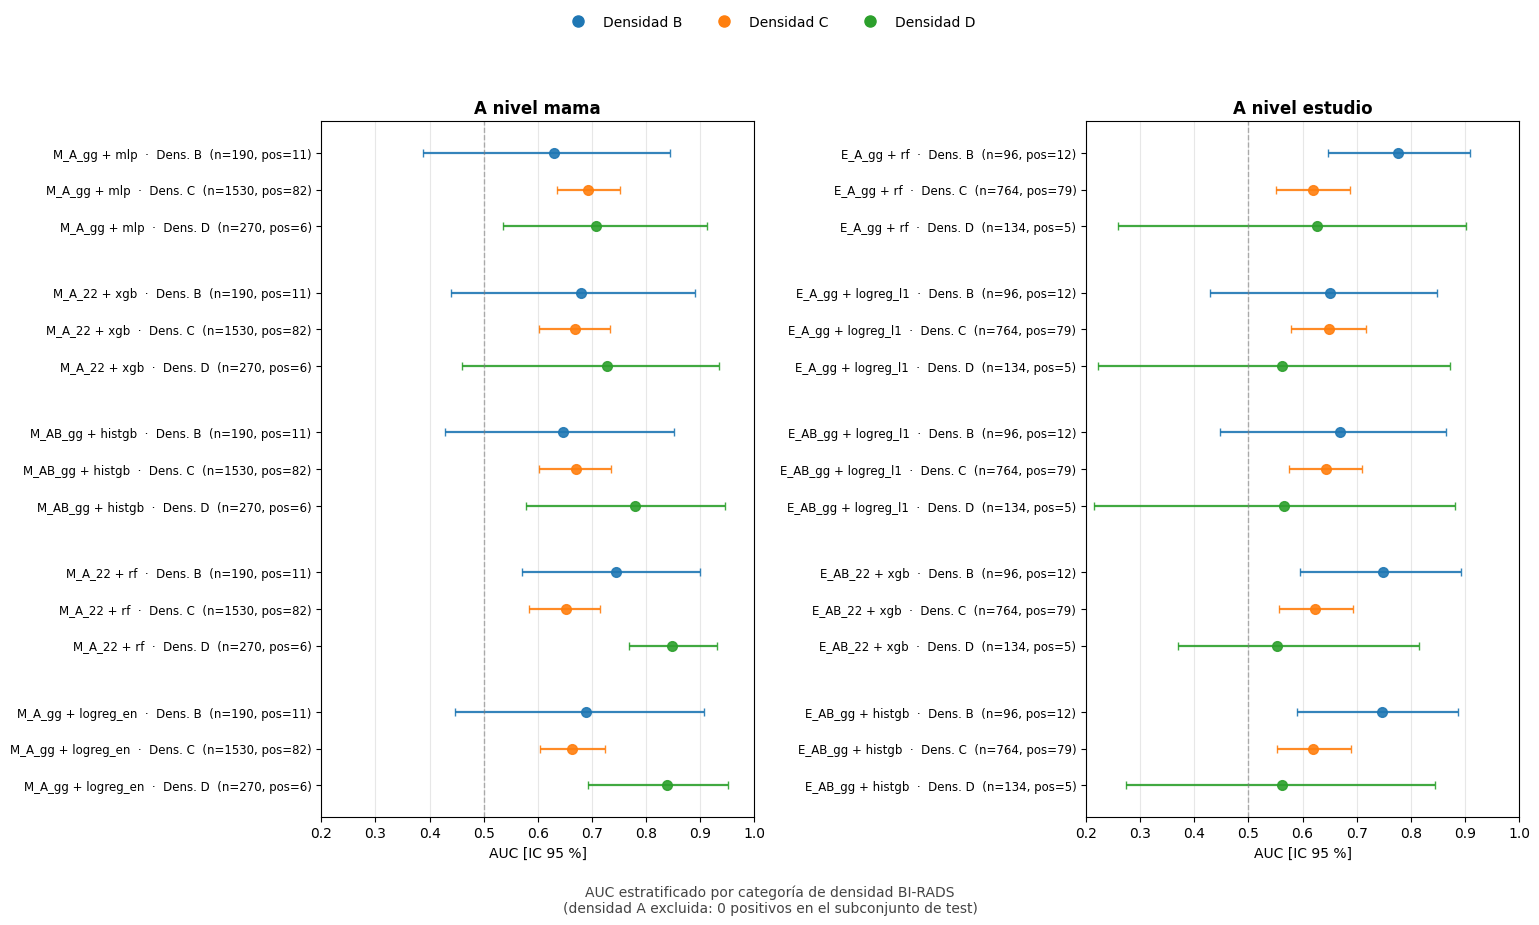

Guardado: forest_densidad.png


In [11]:
def auc_por_estrato(y_true, y_pred, densities, n_boot=1000):
    """Calcula AUC + IC95% por estrato de densidad."""
    rows = []
    for d in ['A', 'B', 'C', 'D']:
        mask = densities == d
        n = int(mask.sum())
        n_pos = int(y_true[mask].sum())
        if n_pos < 2 or (n - n_pos) < 2:
            rows.append({'densidad': d, 'n': n, 'n_pos': n_pos, 'auc': np.nan, 'auc_lo': np.nan, 'auc_hi': np.nan})
            continue
        auc, lo, hi = bootstrap_metric_ci(y_true[mask], y_pred[mask], roc_auc_score, n_boot=n_boot)
        rows.append({'densidad': d, 'n': n, 'n_pos': n_pos, 'auc': auc, 'auc_lo': lo, 'auc_hi': hi})
    return pd.DataFrame(rows)

# Aplicar a las 5 mejores configuraciones por nivel
density_rows = []
top_by_level = {
    'mama':    df_eval[df_eval.level == 'mama'].nlargest(5, 'auc'),
    'estudio': df_eval[df_eval.level == 'estudio'].nlargest(5, 'auc'),
}

for level, top in top_by_level.items():
    densities = density_M_test if level == 'mama' else density_E_test
    y_test = y_M_test if level == 'mama' else y_E_test
    print(f'\n=== {level.upper()} ===')
    for _, r in top.iterrows():
        _, test_pred = load_predictions(r['config'], r['head'])
        df_d = auc_por_estrato(y_test, test_pred, densities)
        df_d.insert(0, 'config', r['config']); df_d.insert(1, 'head', r['head']); df_d.insert(2, 'level', level)
        density_rows.append(df_d)
        print(f'\n  {r["config"]}__{r["head"]}  (AUC global = {r["auc"]:.4f})')
        for _, dr in df_d.iterrows():
            if not np.isnan(dr['auc']):
                print(f'    {dr["densidad"]}: n={dr["n"]:4d}  pos={dr["n_pos"]:3d}  AUC={dr["auc"]:.4f} [{dr["auc_lo"]:.4f}, {dr["auc_hi"]:.4f}]')
            else:
                print(f'    {dr["densidad"]}: n={dr["n"]:4d}  pos={dr["n_pos"]:3d}  AUC=NaN (n_pos insuficiente)')

df_density = pd.concat(density_rows, ignore_index=True)
df_density.to_csv(os.path.join(PRED_DIR_V2, 'eval_densidad_v2.csv'), index=False)
print(f'\nGuardado: eval_densidad_v2.csv')

# ─────────────────────────────────────────────────────────────────────
# FOREST PLOT — Ilustración 11 de la memoria
# (añadido en Hito 3: cierra el hueco de la figura citada)
# ─────────────────────────────────────────────────────────────────────
_color_dens = {'B': '#1f77b4', 'C': '#ff7f0e', 'D': '#2ca02c'}
_dens_show = ['B', 'C', 'D']  # A se excluye (0 positivos en test)

fig, axes = plt.subplots(1, 2, figsize=(15.5, 9), sharex=True)

for ax_idx, level in enumerate(['mama', 'estudio']):
    ax = axes[ax_idx]
    df_sub = df_density[df_density.level == level]
    top = top_by_level[level]
    yticks, yticklabels, y_pos = [], [], 0

    for _, tr in top.iterrows():
        cfg, head = tr['config'], tr['head']
        for d in _dens_show:
            r_sub = df_sub[(df_sub['config']==cfg)&(df_sub['head']==head)&(df_sub['densidad']==d)]
            if len(r_sub) == 0:
                continue
            r = r_sub.iloc[0]
            if not np.isnan(r['auc']):
                ax.errorbar(r['auc'], y_pos,
                            xerr=[[r['auc']-r['auc_lo']], [r['auc_hi']-r['auc']]],
                            fmt='o', color=_color_dens[d], capsize=3, markersize=7, linewidth=1.6, alpha=0.9)
                label = f'{cfg} + {head}  ·  Dens. {d}  (n={r["n"]}, pos={r["n_pos"]})'
            else:
                label = f'{cfg} + {head}  ·  Dens. {d}  (n insuf.)'
            yticks.append(y_pos); yticklabels.append(label); y_pos += 1
        y_pos += 0.8

    ax.set_yticks(yticks); ax.set_yticklabels(yticklabels, fontsize=8.5)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xlim(0.2, 1.0); ax.set_xlabel('AUC [IC 95 %]')
    ax.set_title(f'A nivel {level}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='x'); ax.invert_yaxis()

_handles = [plt.Line2D([], [], marker='o', color=c, linestyle='', markersize=8, label=f'Densidad {d}')
            for d, c in _color_dens.items()]
fig.legend(handles=_handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.00), frameon=False, fontsize=10)
fig.suptitle('AUC estratificado por categoría de densidad BI-RADS\n(densidad A excluida: 0 positivos en el subconjunto de test)',
             y=0.02, fontsize=10, color='#444')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig(os.path.join(PRED_DIR_V2, 'forest_densidad.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: forest_densidad.png')


## 6.b Análisis estratificado por rango de edad

Añadido en Hito 3 a petición de la tutora. La edad se extrae del metadato DICOM `Patient's Age` (formato "053Y") y se agrupa en rangos clínicamente relevantes. Se excluyen los estudios sin edad válida (≈565 de 4999, ~11 % del dataset).

Este análisis complementa al de densidad y ayuda a caracterizar posibles diferencias de rendimiento a lo largo del ciclo vital de las pacientes, un factor conocidamente relevante en cribado (a mayor edad, mayor prevalencia de cáncer).



=== MAMA — AUC por rango de edad ===

  M_A_gg__mlp  (AUC global = 0.6866)
    20-39   n= 476  pos= 14  AUC=0.5657 [0.418, 0.725]
    40-49   n= 724  pos= 31  AUC=0.7159 [0.615, 0.811]
    50-59   n= 392  pos= 18  AUC=0.5612 [0.405, 0.714]
    60-69   n= 118  pos= 12  AUC=0.5896 [0.412, 0.774]
    70+     n=  28  pos=  7  AUC=0.6803 [0.394, 0.947]

  M_A_22__xgb  (AUC global = 0.6813)
    20-39   n= 476  pos= 14  AUC=0.5277 [0.359, 0.700]
    40-49   n= 724  pos= 31  AUC=0.6905 [0.592, 0.779]
    50-59   n= 392  pos= 18  AUC=0.5416 [0.371, 0.706]
    60-69   n= 118  pos= 12  AUC=0.7673 [0.537, 0.936]
    70+     n=  28  pos=  7  AUC=0.8707 [0.681, 1.000]

  M_AB_gg__histgb  (AUC global = 0.6811)
    20-39   n= 476  pos= 14  AUC=0.6169 [0.464, 0.760]
    40-49   n= 724  pos= 31  AUC=0.6767 [0.563, 0.780]
    50-59   n= 392  pos= 18  AUC=0.5547 [0.389, 0.706]
    60-69   n= 118  pos= 12  AUC=0.6352 [0.431, 0.829]
    70+     n=  28  pos=  7  AUC=0.7891 [0.565, 1.000]

  M_A_22__rf  (AUC

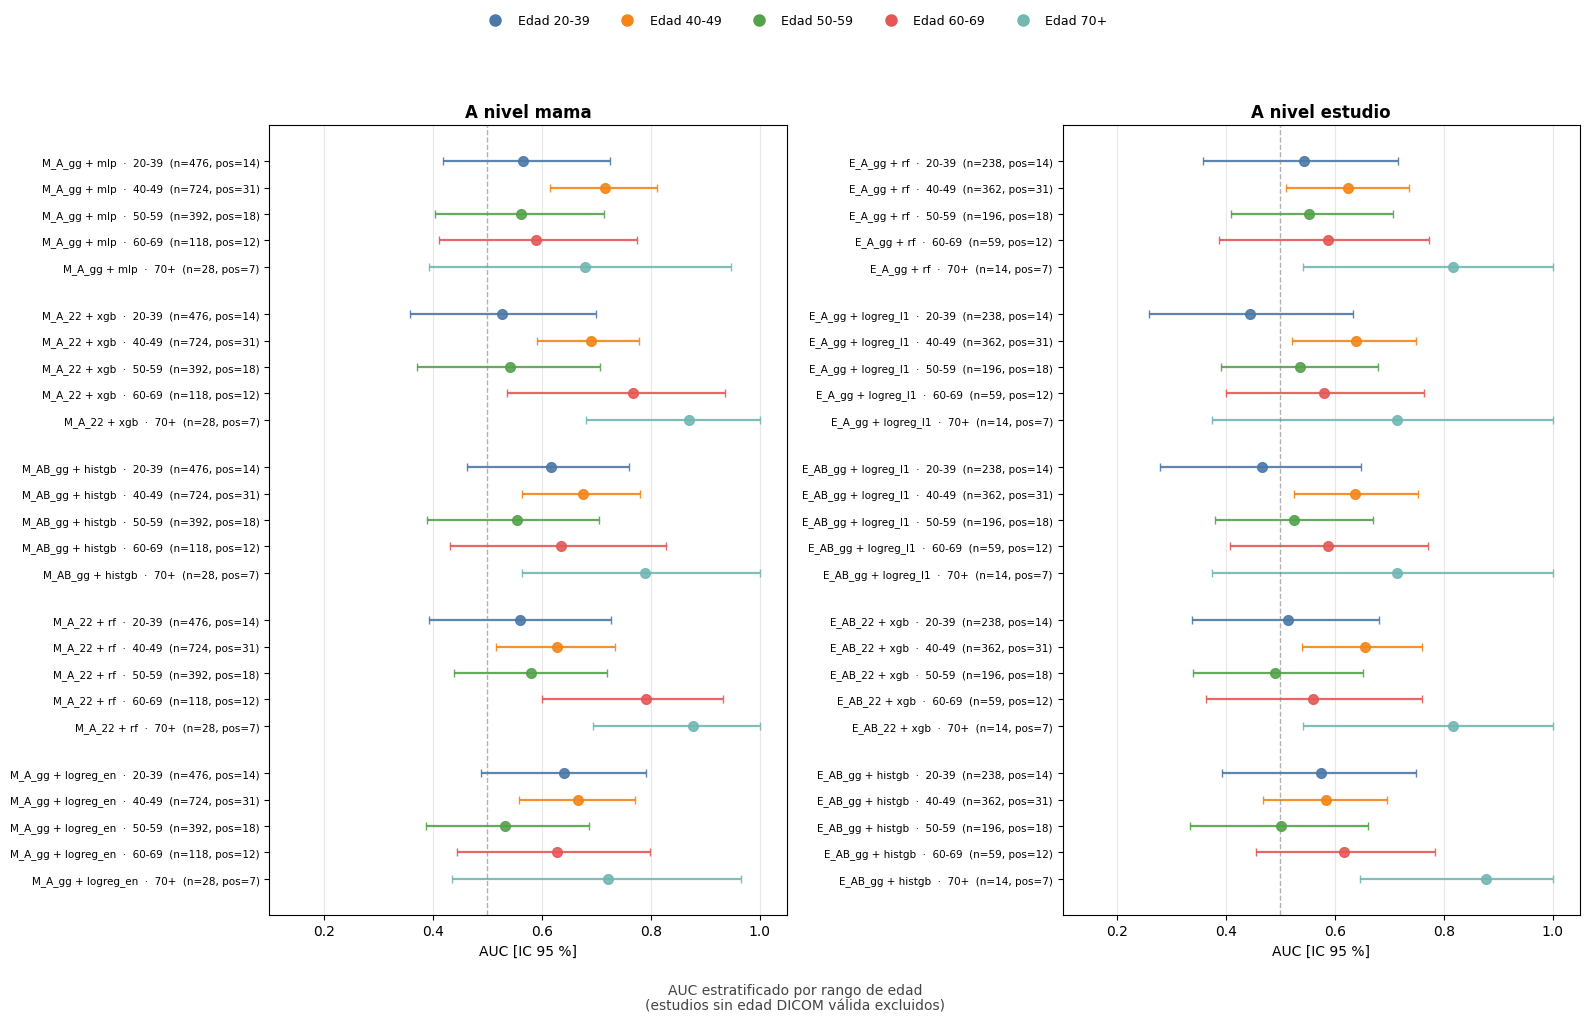

Guardado: forest_edad.png


In [12]:
if HAS_EXTRA_ANNS:
    def auc_por_edad(y_true, y_pred, age_bins, n_boot=1000):
        """Calcula AUC + IC95% por rango de edad."""
        valid = ~pd.isna(age_bins)
        valid_arr = np.asarray(valid)
        y = y_true[valid_arr]; p = y_pred[valid_arr]
        ab = np.asarray(age_bins)[valid_arr]
        rows = []
        for b in ['20-39', '40-49', '50-59', '60-69', '70+']:
            mask = ab == b
            n = int(mask.sum())
            n_pos = int(y[mask].sum())
            if n_pos < 2 or (n - n_pos) < 2:
                rows.append({'bin': b, 'n': n, 'n_pos': n_pos, 'auc': np.nan, 'auc_lo': np.nan, 'auc_hi': np.nan})
                continue
            auc, lo, hi = bootstrap_metric_ci(y[mask], p[mask], roc_auc_score, n_boot=n_boot)
            rows.append({'bin': b, 'n': n, 'n_pos': n_pos, 'auc': auc, 'auc_lo': lo, 'auc_hi': hi})
        return pd.DataFrame(rows)

    age_rows = []
    for level, top in top_by_level.items():
        age_bins = age_bin_M_test if level == 'mama' else age_bin_E_test
        y_test = y_M_test if level == 'mama' else y_E_test
        print(f'\n=== {level.upper()} — AUC por rango de edad ===')
        for _, r in top.iterrows():
            _, test_pred = load_predictions(r['config'], r['head'])
            df_a = auc_por_edad(y_test, test_pred, age_bins)
            df_a.insert(0, 'config', r['config']); df_a.insert(1, 'head', r['head']); df_a.insert(2, 'level', level)
            age_rows.append(df_a)
            print(f'\n  {r["config"]}__{r["head"]}  (AUC global = {r["auc"]:.4f})')
            for _, dr in df_a.iterrows():
                if not np.isnan(dr['auc']):
                    print(f'    {dr["bin"]:6s}  n={dr["n"]:4d}  pos={dr["n_pos"]:3d}  AUC={dr["auc"]:.4f} [{dr["auc_lo"]:.3f}, {dr["auc_hi"]:.3f}]')
                else:
                    print(f'    {dr["bin"]:6s}  n={dr["n"]:4d}  pos={dr["n_pos"]:3d}  AUC=NaN (n insuf.)')

    df_edad = pd.concat(age_rows, ignore_index=True)
    df_edad.to_csv(os.path.join(PRED_DIR_V2, 'eval_edad_v2.csv'), index=False)
    print(f'\nGuardado: eval_edad_v2.csv')

    # Forest plot edad
    _color_edad = {'20-39':'#4c78a8', '40-49':'#f58518', '50-59':'#54a24b', '60-69':'#e45756', '70+':'#72b7b2'}
    _age_labels = ['20-39', '40-49', '50-59', '60-69', '70+']
    fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharex=True)

    for ax_idx, level in enumerate(['mama', 'estudio']):
        ax = axes[ax_idx]
        df_sub = df_edad[df_edad.level == level]
        top = top_by_level[level]
        yticks, yticklabels, y_pos = [], [], 0

        for _, tr in top.iterrows():
            cfg, head = tr['config'], tr['head']
            for b in _age_labels:
                r_sub = df_sub[(df_sub['config']==cfg)&(df_sub['head']==head)&(df_sub['bin']==b)]
                if len(r_sub) == 0:
                    continue
                r = r_sub.iloc[0]
                if not np.isnan(r['auc']):
                    ax.errorbar(r['auc'], y_pos,
                                xerr=[[r['auc']-r['auc_lo']], [r['auc_hi']-r['auc']]],
                                fmt='o', color=_color_edad[b], capsize=3, markersize=7, linewidth=1.6, alpha=0.9)
                    label = f'{cfg} + {head}  ·  {b}  (n={r["n"]}, pos={r["n_pos"]})'
                else:
                    label = f'{cfg} + {head}  ·  {b}  (n insuf.)'
                yticks.append(y_pos); yticklabels.append(label); y_pos += 1
            y_pos += 0.8

        ax.set_yticks(yticks); ax.set_yticklabels(yticklabels, fontsize=7.5)
        ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
        ax.set_xlim(0.1, 1.05); ax.set_xlabel('AUC [IC 95 %]')
        ax.set_title(f'A nivel {level}', fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3, axis='x'); ax.invert_yaxis()

    _handles = [plt.Line2D([], [], marker='o', color=c, linestyle='', markersize=8, label=f'Edad {b}')
                for b, c in _color_edad.items()]
    fig.legend(handles=_handles, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.00), frameon=False, fontsize=9)
    fig.suptitle('AUC estratificado por rango de edad\n(estudios sin edad DICOM válida excluidos)',
                 y=0.02, fontsize=10, color='#444')
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.savefig(os.path.join(PRED_DIR_V2, 'forest_edad.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: forest_edad.png')
else:
    print('Análisis por edad no disponible (DICOM metadata no encontrado).')


## 6.c Análisis de errores por categoría BI-RADS original

Añadido en Hito 3 a petición de la tutora. El clasificador binario colapsa las cinco categorías BI-RADS en dos (1-3 vs 4-5), lo que oculta si el modelo distingue correctamente los extremos (BI-RADS 1 muy claramente negativo, BI-RADS 5 muy claramente positivo) o si comete errores concentrados en categorías intermedias (BI-RADS 3 y 4, la zona clínicamente ambigua).

Este análisis produce dos evidencias complementarias:

1. **Distribución del score predicho por cada categoría BI-RADS 1-5** (boxplot) — muestra si hay solapamiento entre categorías adyacentes.
2. **AUC pareado entre categorías** — cuantifica la separabilidad entre pares específicos (p. ej. BI-RADS 5 vs BI-RADS 1 debería tener AUC alto; BI-RADS 4 vs BI-RADS 3 debería tener AUC bajo).


M_A_22       (estudio, calibrado): AUC global = 0.6891
M_A_gg + mlp (mama, calibrado):    AUC global = 0.6866


C:\Users\victo\AppData\Local\Temp\ipykernel_20632\1897036043.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', fontsize=9)
C:\Users\victo\AppData\Local\Temp\ipykernel_20632\1897036043.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', fontsize=9)


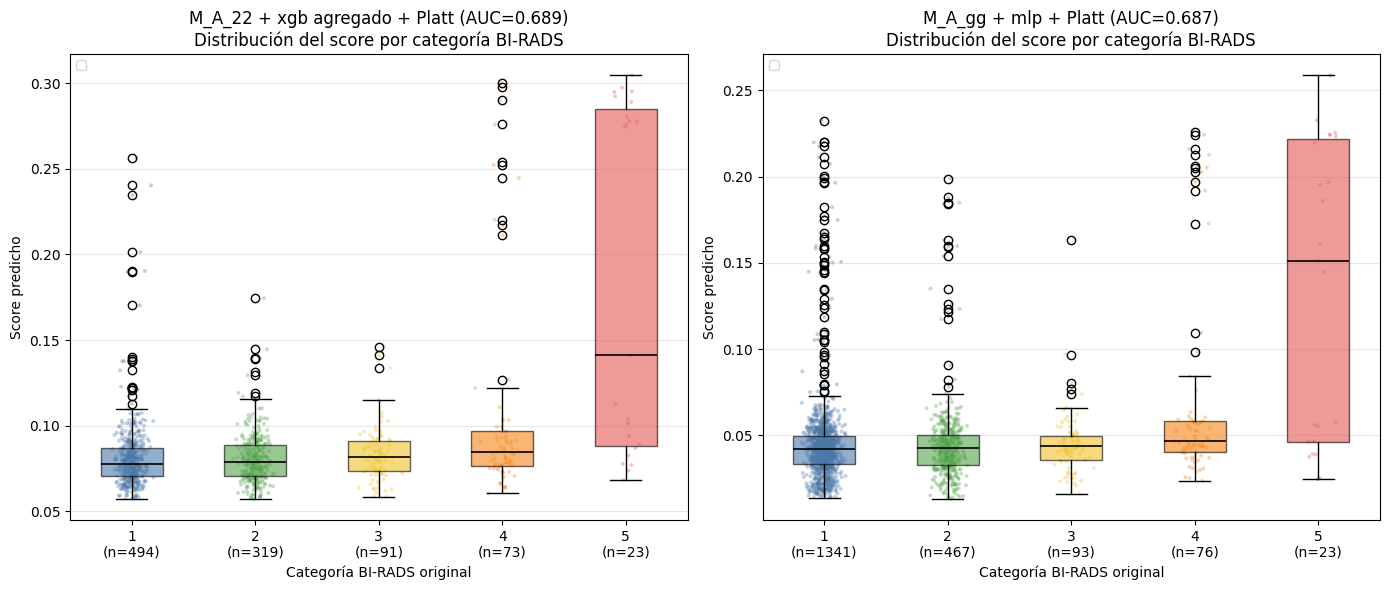

Guardado: score_por_birads.png

=== AUC pareado entre categorías BI-RADS (test hold-out) ===

M_A_22+xgb agregado + Platt:
  BI-RADS 4 vs 1:  n_pos= 73  n_neg= 494  AUC=0.6518
  BI-RADS 4 vs 2:  n_pos= 73  n_neg= 319  AUC=0.6416
  BI-RADS 4 vs 3:  n_pos= 73  n_neg=  91  AUC=0.5954
  BI-RADS 5 vs 1:  n_pos= 23  n_neg= 494  AUC=0.8420
  BI-RADS 5 vs 2:  n_pos= 23  n_neg= 319  AUC=0.8359
  BI-RADS 5 vs 3:  n_pos= 23  n_neg=  91  AUC=0.8137

M_A_gg+mlp + Platt:
  BI-RADS 4 vs 1:  n_pos= 76  n_neg=1341  AUC=0.6586
  BI-RADS 4 vs 2:  n_pos= 76  n_neg= 467  AUC=0.6478
  BI-RADS 4 vs 3:  n_pos= 76  n_neg=  93  AUC=0.6269
  BI-RADS 5 vs 1:  n_pos= 23  n_neg=1341  AUC=0.7959
  BI-RADS 5 vs 2:  n_pos= 23  n_neg= 467  AUC=0.7889
  BI-RADS 5 vs 3:  n_pos= 23  n_neg=  93  AUC=0.7737

Guardado: auc_pairwise_birads.csv

─── Interpretación ───
Se espera que BI-RADS 5 vs 1 tenga AUC alto (extremos bien separados).
Se espera que BI-RADS 4 vs 3 tenga AUC más bajo (categorías adyacentes ambiguas).
Ese patr

In [23]:
if HAS_EXTRA_ANNS:
    # ─────────────────────────────────────────────────────────────────
    # Modelos a analizar: los DOS MODELOS FINALES calibrados con Platt
    # (Sección 5.5.2 del TFM). Se cargan los scores calibrados directamente
    # desde CALIB_DIR (producidos por NB12) en lugar de reconstruirlos.
    #
    # Nota: los AUC son idénticos con o sin Platt (transformación monótona),
    # pero las distribuciones del score cambian: los scores calibrados están
    # comprimidos cerca de la prevalencia real, coherente con la interpretación
    # probabilística del modelo final del TFM.
    # ─────────────────────────────────────────────────────────────────
    CALIB_DIR = os.path.join(PRED_DIR_V2, 'calibracion_predicciones')

    # 1) Modelo triaje: M_A_22 + xgb agregado a estudio + Platt (calibrado)
    p_E_final = np.load(os.path.join(CALIB_DIR, 'M_A_22__xgb_agg_E__platt_test.npy'))
    assert len(p_E_final) == len(y_E_test), 'Desalineación score triaje vs y_E_test'

    # 2) Modelo localización: M_A_gg + mlp a nivel mama + Platt (calibrado)
    p_M_mlp = np.load(os.path.join(CALIB_DIR, 'M_A_gg__mlp_mama__platt_test.npy'))
    assert len(p_M_mlp) == len(y_M_test), 'Desalineación score localización vs y_M_test'

    print(f'M_A_22       (estudio, calibrado): AUC global = {roc_auc_score(y_E_test, p_E_final):.4f}')
    print(f'M_A_gg + mlp (mama, calibrado):    AUC global = {roc_auc_score(y_M_test, p_M_mlp):.4f}')

    # ─── Boxplots con jitter ───
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    _cats = [1, 2, 3, 4, 5]
    _colors_bp = ['#4c78a8', '#54a24b', '#f0c22a', '#f58518', '#e45756']
    _rng = np.random.default_rng(SEED)

    for ax, (score, birads_orig, title, auc_ref) in zip(axes, [
        (p_E_final, birads_E_orig_test, 'M_A_22 + xgb agregado + Platt', 0.689),
        (p_M_mlp,   birads_M_orig_test, 'M_A_gg + mlp + Platt', 0.687),
    ]):
        data_by_cat = [score[birads_orig == b] for b in _cats]
        bp = ax.boxplot(data_by_cat, positions=_cats, widths=0.5, patch_artist=True,
                        medianprops=dict(color='black', linewidth=1.2))
        for patch, c in zip(bp['boxes'], _colors_bp):
            patch.set_facecolor(c); patch.set_alpha(0.6)
        for i, b in enumerate(_cats):
            data = score[birads_orig == b]
            x_jitter = _rng.normal(loc=b, scale=0.06, size=len(data))
            ax.scatter(x_jitter, data, s=8, alpha=0.35, color=_colors_bp[i], edgecolors='none')
        ax.set_xlabel('Categoría BI-RADS original')
        ax.set_ylabel('Score predicho')
        ax.set_title(f'{title} (AUC={auc_ref:.3f})\nDistribución del score por categoría BI-RADS')
        ax.set_xticks(_cats)
        ax.set_xticklabels([f'{b}\n(n={(birads_orig==b).sum()})' for b in _cats])
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(os.path.join(PRED_DIR_V2, 'score_por_birads.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: score_por_birads.png')

    # ─── AUC pairwise entre categorías ───
    def _pairwise_auc(scores_pos, scores_neg):
        if len(scores_pos) < 2 or len(scores_neg) < 2:
            return np.nan
        y_pair = np.concatenate([np.ones(len(scores_pos)), np.zeros(len(scores_neg))])
        s_pair = np.concatenate([scores_pos, scores_neg])
        return roc_auc_score(y_pair, s_pair)

    pw_rows = []
    for nombre, score, birads_orig in [
        ('M_A_22+xgb agregado + Platt', p_E_final, birads_E_orig_test),
        ('M_A_gg+mlp + Platt',    p_M_mlp,   birads_M_orig_test),
    ]:
        for pos_b in [4, 5]:
            for neg_b in [1, 2, 3]:
                pos = score[birads_orig == pos_b]
                neg = score[birads_orig == neg_b]
                a = _pairwise_auc(pos, neg)
                pw_rows.append({'modelo': nombre, 'pos_birads': pos_b, 'neg_birads': neg_b,
                                'n_pos': len(pos), 'n_neg': len(neg), 'auc_pairwise': a})

    df_pw = pd.DataFrame(pw_rows)
    print('\n=== AUC pareado entre categorías BI-RADS (test hold-out) ===')
    for nombre in df_pw['modelo'].unique():
        print(f'\n{nombre}:')
        sub = df_pw[df_pw['modelo'] == nombre]
        for _, r in sub.iterrows():
            print(f'  BI-RADS {r["pos_birads"]} vs {r["neg_birads"]}:  n_pos={r["n_pos"]:3d}  n_neg={r["n_neg"]:4d}  AUC={r["auc_pairwise"]:.4f}')

    df_pw.to_csv(os.path.join(PRED_DIR_V2, 'auc_pairwise_birads.csv'), index=False)
    print('\nGuardado: auc_pairwise_birads.csv')

    # Interpretación resumida
    print('\n─── Interpretación ───')
    print('Se espera que BI-RADS 5 vs 1 tenga AUC alto (extremos bien separados).')
    print('Se espera que BI-RADS 4 vs 3 tenga AUC más bajo (categorías adyacentes ambiguas).')
    print('Ese patrón valida clínicamente al modelo: comete errores donde también los cometería el radiólogo.')
else:
    print('Análisis por BI-RADS original no disponible (DICOM metadata no encontrado).')


## 6.d Análisis por subgrupos del modelo final calibrado

**Sección añadida a raíz del feedback de Karen (Hito 3).**

Los análisis anteriores (6, 6.b, 6.c) se aplican sobre los **top-5 modelos por AUC test ensemble sin agregación ni calibración post-hoc**. Aunque ese ranking es útil como sondeo exploratorio, no coincide con los **modelos finales calibrados** definidos en la Sección 5.5.2 del TFM. Esta sección reproduce el análisis por densidad y edad específicamente sobre los dos modelos finales:

- **Triaje a nivel estudio**: `M_A_22 + xgb` agregado a estudio con calibración Platt. AUC global = 0,689.
- **Localización a nivel mama**: `M_A_gg + mlp` con calibración Platt. AUC global = 0,687.

Ambos scores calibrados se cargan directamente desde `outputs/Predicciones_v2/calibracion_predicciones/`, producidos por el NB12. Las funciones `auc_por_estrato` y `auc_por_edad` se reutilizan de las celdas anteriores (6 y 6.b). Los resultados de esta sección son los que se citan en las secciones 5.6 y 5.7 del TFM.

In [14]:
# Cargar scores calibrados de los dos modelos finales (producidos por NB12) ──
CALIB_DIR = os.path.join(PRED_DIR_V2, 'calibracion_predicciones')

# Triaje (nivel estudio): M_A_22 + xgb agregado + Platt
score_final_E = np.load(os.path.join(CALIB_DIR, 'M_A_22__xgb_agg_E__platt_test.npy'))
assert len(score_final_E) == len(y_E_test), 'Desalineación score triaje vs y_E_test'

# Localización (nivel mama): M_A_gg + mlp + Platt
score_final_M = np.load(os.path.join(CALIB_DIR, 'M_A_gg__mlp_mama__platt_test.npy'))
assert len(score_final_M) == len(y_M_test), 'Desalineación score localización vs y_M_test'

print(f'Modelo triaje       (nivel estudio):  n={len(score_final_E):4d}   AUC global = {roc_auc_score(y_E_test, score_final_E):.4f}')
print(f'Modelo localización (nivel mama):     n={len(score_final_M):4d}   AUC global = {roc_auc_score(y_M_test, score_final_M):.4f}')

Modelo triaje       (nivel estudio):  n=1000   AUC global = 0.6891
Modelo localización (nivel mama):     n=2000   AUC global = 0.6866


In [15]:
# AUC por densidad — reutiliza la función auc_por_estrato definida en la celda 17

# ── Modelo triaje (nivel estudio) ────────────────────────────────────
df_E_density = auc_por_estrato(y_E_test, score_final_E, density_E_test, n_boot=1000)
df_E_density.insert(0, 'level',  'estudio')
df_E_density.insert(1, 'modelo', 'M_A_22 + xgb (agregado + Platt)')
print('─── Modelo triaje (nivel estudio) — AUC por densidad ───')
for _, r in df_E_density.iterrows():
    if not np.isnan(r['auc']):
        print(f'  Dens. {r["densidad"]}: n={r["n"]:4d}  pos={r["n_pos"]:3d}  AUC={r["auc"]:.4f} [{r["auc_lo"]:.3f}, {r["auc_hi"]:.3f}]')
    else:
        print(f'  Dens. {r["densidad"]}: n={r["n"]:4d}  pos={r["n_pos"]:3d}  AUC=NaN (n insuficiente)')

# ── Modelo localización (nivel mama) ─────────────────────────────────
df_M_density = auc_por_estrato(y_M_test, score_final_M, density_M_test, n_boot=1000)
df_M_density.insert(0, 'level',  'mama')
df_M_density.insert(1, 'modelo', 'M_A_gg + mlp (Platt)')
print('\n─── Modelo localización (nivel mama) — AUC por densidad ───')
for _, r in df_M_density.iterrows():
    if not np.isnan(r['auc']):
        print(f'  Dens. {r["densidad"]}: n={r["n"]:4d}  pos={r["n_pos"]:3d}  AUC={r["auc"]:.4f} [{r["auc_lo"]:.3f}, {r["auc_hi"]:.3f}]')
    else:
        print(f'  Dens. {r["densidad"]}: n={r["n"]:4d}  pos={r["n_pos"]:3d}  AUC=NaN (n insuficiente)')

df_density_final = pd.concat([df_E_density, df_M_density], ignore_index=True)
df_density_final.to_csv(os.path.join(PRED_DIR_V2, 'eval_densidad_modelo_final.csv'), index=False)
print(f'\nGuardado: eval_densidad_modelo_final.csv')

─── Modelo triaje (nivel estudio) — AUC por densidad ───
  Dens. A: n=   6  pos=  0  AUC=NaN (n insuficiente)
  Dens. B: n=  96  pos= 12  AUC=0.7649 [0.612, 0.899]
  Dens. C: n= 764  pos= 79  AUC=0.6638 [0.591, 0.729]
  Dens. D: n= 134  pos=  5  AUC=0.6977 [0.392, 0.998]

─── Modelo localización (nivel mama) — AUC por densidad ───
  Dens. A: n=  10  pos=  0  AUC=NaN (n insuficiente)
  Dens. B: n= 190  pos= 11  AUC=0.6298 [0.388, 0.845]
  Dens. C: n=1530  pos= 82  AUC=0.6926 [0.636, 0.751]
  Dens. D: n= 270  pos=  6  AUC=0.7071 [0.536, 0.912]

Guardado: eval_densidad_modelo_final.csv


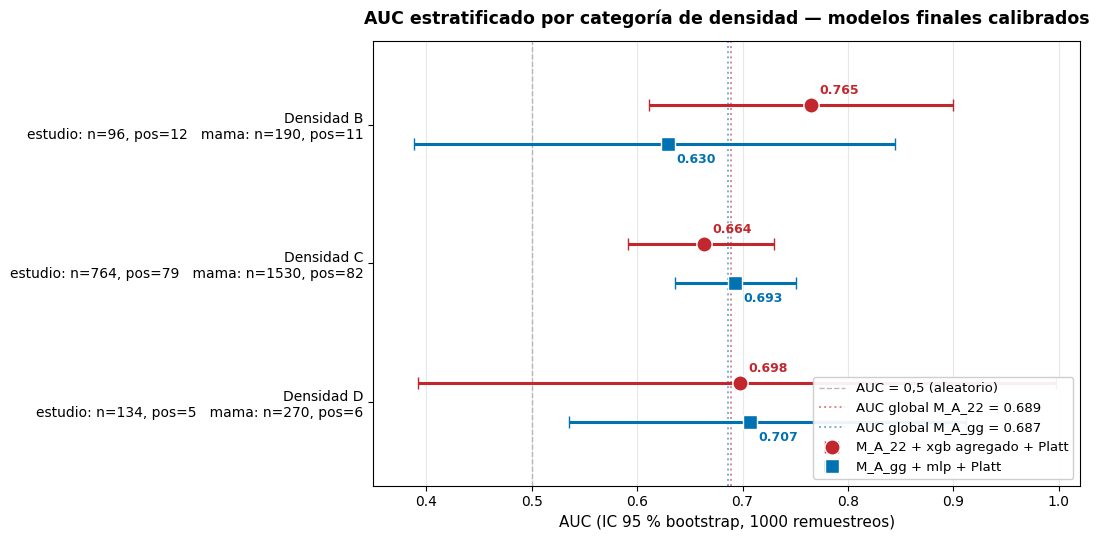

Guardado: auc_densidad_modelo_final.png


In [16]:
# Ilustración 16 nueva — AUC por densidad: ambos modelos superpuestos ──
_dens_show = ['B', 'C', 'D']

# AUC globales para líneas de referencia
auc_global_E = roc_auc_score(y_E_test, score_final_E)
auc_global_M = roc_auc_score(y_M_test, score_final_M)

fig, ax = plt.subplots(figsize=(11, 5.5))

# Offset vertical para que los IC de ambos modelos no se solapen
OFFSET = 0.14

# --- Modelo triaje (estudio) — círculo rojo, ligeramente arriba ---
for i, d in enumerate(_dens_show):
    r = df_E_density[df_E_density['densidad'] == d].iloc[0]
    if np.isnan(r['auc']):
        continue
    ax.errorbar(r['auc'], i - OFFSET,
                xerr=[[r['auc']-r['auc_lo']], [r['auc_hi']-r['auc']]],
                fmt='o', color='#c1272d', capsize=4, markersize=11, linewidth=2.2,
                label='M_A_22 + xgb agregado + Platt' if i == 0 else None,
                markeredgecolor='white', markeredgewidth=1.0, zorder=3)
    # Anotación con AUC
    ax.annotate(f'{r["auc"]:.3f}', xy=(r['auc'], i - OFFSET),
                xytext=(6, 8), textcoords='offset points',
                fontsize=9, color='#c1272d', fontweight='bold')

# --- Modelo localización (mama) — cuadrado azul, ligeramente abajo ---
for i, d in enumerate(_dens_show):
    r = df_M_density[df_M_density['densidad'] == d].iloc[0]
    if np.isnan(r['auc']):
        continue
    ax.errorbar(r['auc'], i + OFFSET,
                xerr=[[r['auc']-r['auc_lo']], [r['auc_hi']-r['auc']]],
                fmt='s', color='#0072b2', capsize=4, markersize=10, linewidth=2.2,
                label='M_A_gg + mlp + Platt' if i == 0 else None,
                markeredgecolor='white', markeredgewidth=1.0, zorder=3)
    ax.annotate(f'{r["auc"]:.3f}', xy=(r['auc'], i + OFFSET),
                xytext=(6, -14), textcoords='offset points',
                fontsize=9, color='#0072b2', fontweight='bold')

# Líneas de referencia
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.55, zorder=1,
           label='AUC = 0,5 (aleatorio)')
ax.axvline(auc_global_E, color='#c1272d', linestyle=':', linewidth=1.4, alpha=0.55, zorder=1,
           label=f'AUC global M_A_22 = {auc_global_E:.3f}')
ax.axvline(auc_global_M, color='#0072b2', linestyle=':', linewidth=1.4, alpha=0.55, zorder=1,
           label=f'AUC global M_A_gg = {auc_global_M:.3f}')

# Etiquetas del eje Y con n y positivos por densidad
yticklabels = []
for d in _dens_show:
    rE = df_E_density[df_E_density['densidad'] == d].iloc[0]
    rM = df_M_density[df_M_density['densidad'] == d].iloc[0]
    lbl = (f'Densidad {d}\n'
           f'estudio: n={int(rE["n"])}, pos={int(rE["n_pos"])}   '
           f'mama: n={int(rM["n"])}, pos={int(rM["n_pos"])}')
    yticklabels.append(lbl)
ax.set_yticks(range(len(_dens_show)))
ax.set_yticklabels(yticklabels, fontsize=10)

ax.set_xlabel('AUC (IC 95 % bootstrap, 1000 remuestreos)', fontsize=11)
ax.set_title('AUC estratificado por categoría de densidad — modelos finales calibrados',
             fontsize=12.5, fontweight='bold', pad=12)
ax.set_xlim(0.35, 1.02)
ax.set_ylim(-0.6, len(_dens_show) - 0.4)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
ax.legend(loc='lower right', fontsize=9.5, framealpha=0.93, ncol=1)

plt.tight_layout()
plt.savefig(os.path.join(PRED_DIR_V2, 'auc_densidad_modelo_final.png'),
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Guardado: auc_densidad_modelo_final.png')

In [17]:
# AUC por rango de edad — reutiliza la función auc_por_edad definida en la celda 19

# ── Modelo triaje (nivel estudio) ────────────────────────────────────
df_E_edad = auc_por_edad(y_E_test, score_final_E, age_bin_E_test, n_boot=1000)
df_E_edad.insert(0, 'level',  'estudio')
df_E_edad.insert(1, 'modelo', 'M_A_22 + xgb (agregado + Platt)')
print('─── Modelo triaje (nivel estudio) — AUC por rango de edad ───')
for _, r in df_E_edad.iterrows():
    if not np.isnan(r['auc']):
        print(f'  {r["bin"]:6s}  n={r["n"]:4d}  pos={r["n_pos"]:3d}  AUC={r["auc"]:.4f} [{r["auc_lo"]:.3f}, {r["auc_hi"]:.3f}]')
    else:
        print(f'  {r["bin"]:6s}  n={r["n"]:4d}  pos={r["n_pos"]:3d}  AUC=NaN (n insuf.)')

# ── Modelo localización (nivel mama) ─────────────────────────────────
df_M_edad = auc_por_edad(y_M_test, score_final_M, age_bin_M_test, n_boot=1000)
df_M_edad.insert(0, 'level',  'mama')
df_M_edad.insert(1, 'modelo', 'M_A_gg + mlp (Platt)')
print('\n─── Modelo localización (nivel mama) — AUC por rango de edad ───')
for _, r in df_M_edad.iterrows():
    if not np.isnan(r['auc']):
        print(f'  {r["bin"]:6s}  n={r["n"]:4d}  pos={r["n_pos"]:3d}  AUC={r["auc"]:.4f} [{r["auc_lo"]:.3f}, {r["auc_hi"]:.3f}]')
    else:
        print(f'  {r["bin"]:6s}  n={r["n"]:4d}  pos={r["n_pos"]:3d}  AUC=NaN (n insuf.)')

df_edad_final = pd.concat([df_E_edad, df_M_edad], ignore_index=True)
df_edad_final.to_csv(os.path.join(PRED_DIR_V2, 'eval_edad_modelo_final.csv'), index=False)
print(f'\nGuardado: eval_edad_modelo_final.csv')

─── Modelo triaje (nivel estudio) — AUC por rango de edad ───
  20-39   n= 238  pos= 14  AUC=0.5922 [0.413, 0.762]
  40-49   n= 362  pos= 31  AUC=0.6545 [0.549, 0.753]
  50-59   n= 196  pos= 18  AUC=0.6451 [0.507, 0.781]
  60-69   n=  59  pos= 12  AUC=0.8050 [0.661, 0.936]
  70+     n=  14  pos=  7  AUC=0.9184 [0.729, 1.000]

─── Modelo localización (nivel mama) — AUC por rango de edad ───
  20-39   n= 476  pos= 14  AUC=0.5657 [0.418, 0.725]
  40-49   n= 724  pos= 31  AUC=0.7159 [0.615, 0.811]
  50-59   n= 392  pos= 18  AUC=0.5612 [0.405, 0.714]
  60-69   n= 118  pos= 12  AUC=0.5896 [0.412, 0.774]
  70+     n=  28  pos=  7  AUC=0.6803 [0.394, 0.947]

Guardado: eval_edad_modelo_final.csv


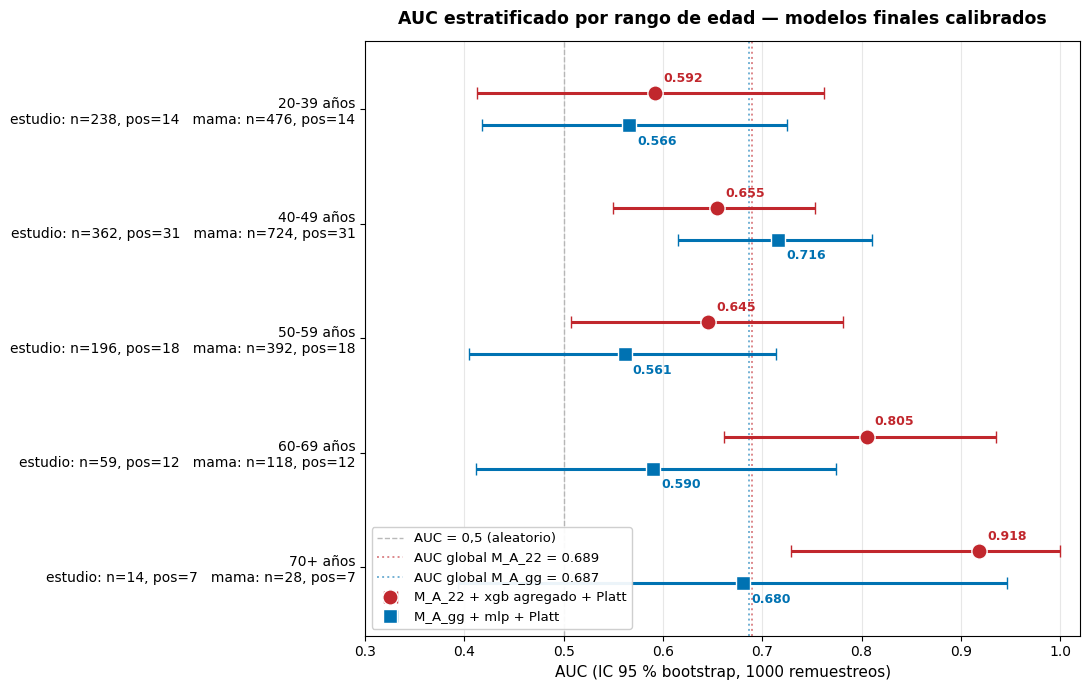

Guardado: auc_edad_modelo_final.png


In [18]:
# Ilustración 17 nueva — AUC por edad: ambos modelos superpuestos ──
_age_labels = ['20-39', '40-49', '50-59', '60-69', '70+']

# AUC globales para líneas de referencia
auc_global_E = roc_auc_score(y_E_test, score_final_E)
auc_global_M = roc_auc_score(y_M_test, score_final_M)

fig, ax = plt.subplots(figsize=(11, 7))

OFFSET = 0.14

# --- Modelo triaje (estudio) — círculo rojo ---
for i, b in enumerate(_age_labels):
    r = df_E_edad[df_E_edad['bin'] == b].iloc[0]
    if np.isnan(r['auc']):
        ax.text(0.5, i - OFFSET, 'n insuficiente', fontsize=9, color='#c1272d', ha='center', va='center')
        continue
    ax.errorbar(r['auc'], i - OFFSET,
                xerr=[[r['auc']-r['auc_lo']], [r['auc_hi']-r['auc']]],
                fmt='o', color='#c1272d', capsize=4, markersize=11, linewidth=2.2,
                label='M_A_22 + xgb agregado + Platt' if i == 0 else None,
                markeredgecolor='white', markeredgewidth=1.0, zorder=3)
    ax.annotate(f'{r["auc"]:.3f}', xy=(r['auc'], i - OFFSET),
                xytext=(6, 8), textcoords='offset points',
                fontsize=9, color='#c1272d', fontweight='bold')

# --- Modelo localización (mama) — cuadrado azul ---
for i, b in enumerate(_age_labels):
    r = df_M_edad[df_M_edad['bin'] == b].iloc[0]
    if np.isnan(r['auc']):
        ax.text(0.5, i + OFFSET, 'n insuficiente', fontsize=9, color='#0072b2', ha='center', va='center')
        continue
    ax.errorbar(r['auc'], i + OFFSET,
                xerr=[[r['auc']-r['auc_lo']], [r['auc_hi']-r['auc']]],
                fmt='s', color='#0072b2', capsize=4, markersize=10, linewidth=2.2,
                label='M_A_gg + mlp + Platt' if i == 0 else None,
                markeredgecolor='white', markeredgewidth=1.0, zorder=3)
    ax.annotate(f'{r["auc"]:.3f}', xy=(r['auc'], i + OFFSET),
                xytext=(6, -14), textcoords='offset points',
                fontsize=9, color='#0072b2', fontweight='bold')

# Líneas de referencia
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.55, zorder=1,
           label='AUC = 0,5 (aleatorio)')
ax.axvline(auc_global_E, color='#c1272d', linestyle=':', linewidth=1.4, alpha=0.55, zorder=1,
           label=f'AUC global M_A_22 = {auc_global_E:.3f}')
ax.axvline(auc_global_M, color='#0072b2', linestyle=':', linewidth=1.4, alpha=0.55, zorder=1,
           label=f'AUC global M_A_gg = {auc_global_M:.3f}')

# Etiquetas del eje Y con n y positivos por rango de edad
yticklabels = []
for b in _age_labels:
    rE = df_E_edad[df_E_edad['bin'] == b].iloc[0]
    rM = df_M_edad[df_M_edad['bin'] == b].iloc[0]
    lbl = (f'{b} años\n'
           f'estudio: n={int(rE["n"])}, pos={int(rE["n_pos"])}   '
           f'mama: n={int(rM["n"])}, pos={int(rM["n_pos"])}')
    yticklabels.append(lbl)
ax.set_yticks(range(len(_age_labels)))
ax.set_yticklabels(yticklabels, fontsize=10)

ax.set_xlabel('AUC (IC 95 % bootstrap, 1000 remuestreos)', fontsize=11)
ax.set_title('AUC estratificado por rango de edad — modelos finales calibrados',
             fontsize=12.5, fontweight='bold', pad=12)
ax.set_xlim(0.30, 1.02)
ax.set_ylim(-0.6, len(_age_labels) - 0.4)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
ax.legend(loc='lower left', fontsize=9.5, framealpha=0.93, ncol=1)

plt.tight_layout()
plt.savefig(os.path.join(PRED_DIR_V2, 'auc_edad_modelo_final.png'),
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Guardado: auc_edad_modelo_final.png')

## 6.e Matrices de confusión de los modelos finales calibrados

**Sección añadida a raíz del feedback de Karen (Hito 3):** *"Para ver mejor fallos vs aciertos y como se equivoca, si puedes metería matrices de confusión"*.

Las matrices de confusión requieren fijar un umbral de decisión. Con los scores calibrados por Platt, los valores están comprimidos cerca de la prevalencia real del dataset (~9,6 % estudio, ~5 % mama), por lo que **el umbral 0,5 no es informativo** (clasificaría prácticamente todo como negativo). Se calculan las matrices sobre **dos puntos operativos clínicamente relevantes** para cada uno de los dos modelos finales calibrados:

1. **Youden index**: umbral que maximiza `sensibilidad + especificidad − 1`. Punto operativo balanceado, estándar académico.
2. **Sensibilidad ≥ 0,85**: umbral que garantiza captura de al menos 85 % de los positivos, con el menor número posible de falsos positivos. Punto operativo orientado a triaje clínico (no perder casos sospechosos).

Los umbrales se determinan sobre las **predicciones OOF calibradas del training pool** (para evitar data-leakage) y se aplican al **test hold-out**. Las OOF se calibran con el mismo procedimiento de Platt del NB12.

Se producen **4 matrices totales** (2 modelos × 2 umbrales) con sus métricas asociadas (sensibilidad, especificidad, VPP, VPN, F1).

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve

def platt_calibrate_local(p_source, y_source, p_target):
    """Reproduce platt_calibrate del NB12 para usar aquí sin dependencia externa."""
    clf = LogisticRegression(C=1e8, solver='lbfgs', max_iter=1000)
    clf.fit(p_source.reshape(-1, 1), y_source)
    return clf.predict_proba(p_target.reshape(-1, 1))[:, 1]

def youden_threshold(y_true, y_score):
    fpr, tpr, thr = roc_curve(y_true, y_score)
    j = tpr - fpr
    ix = int(np.argmax(j))
    return float(thr[ix]), float(tpr[ix]), float(1.0 - fpr[ix]), float(j[ix])

def sens_threshold(y_true, y_score, target_sens=0.75):
    fpr, tpr, thr = roc_curve(y_true, y_score)
    valid = tpr >= target_sens
    if not valid.any():
        return None, None, None
    valid_thr = thr[valid]
    valid_fpr = fpr[valid]
    valid_tpr = tpr[valid]
    ix = int(np.argmin(valid_fpr))
    return float(valid_thr[ix]), float(valid_tpr[ix]), float(1.0 - valid_fpr[ix])

# ─── MODELO TRIAJE (M_A_22 + xgb) ─────────────────────────────────────
# El modelo se entrena a nivel mama pero se aplica a estudio agregando con max(L,R)
p_oof_M_xgb, _ = load_predictions('M_A_22', 'xgb')
p_L_oof = p_oof_M_xgb[:len(y_E_oof)]
p_R_oof = p_oof_M_xgb[len(y_E_oof):]
p_oof_E_agg = np.maximum(p_L_oof, p_R_oof)

# Calibrar Platt sobre OOF agregadas (mismo procedimiento que NB12)
p_oof_E_platt = platt_calibrate_local(p_oof_E_agg, y_E_oof, p_oof_E_agg)

# Determinar umbrales sobre OOF calibradas
t_youden_E, sens_oof_y_E, spec_oof_y_E, j_E = youden_threshold(y_E_oof, p_oof_E_platt)
t_sens_E,   sens_oof_s_E, spec_oof_s_E     = sens_threshold(y_E_oof, p_oof_E_platt, 0.75)

print('─── MODELO TRIAJE (nivel estudio) ─────────────────────────')
print(f'  Umbral Youden:        t = {t_youden_E:.4f}   (OOF: sens={sens_oof_y_E:.3f}, spec={spec_oof_y_E:.3f}, J={j_E:.3f})')
print(f'  Umbral sens ≥ 0,75:   t = {t_sens_E:.4f}   (OOF: sens={sens_oof_s_E:.3f}, spec={spec_oof_s_E:.3f})')

# ─── MODELO LOCALIZACIÓN (M_A_gg + mlp a nivel mama) ─────────────────
p_oof_M_mlp, _ = load_predictions('M_A_gg', 'mlp')
p_oof_M_platt = platt_calibrate_local(p_oof_M_mlp, y_M_oof, p_oof_M_mlp)

t_youden_M, sens_oof_y_M, spec_oof_y_M, j_M = youden_threshold(y_M_oof, p_oof_M_platt)
t_sens_M,   sens_oof_s_M, spec_oof_s_M     = sens_threshold(y_M_oof, p_oof_M_platt, 0.75)

print('\n─── MODELO LOCALIZACIÓN (nivel mama) ─────────────────────')
print(f'  Umbral Youden:        t = {t_youden_M:.4f}   (OOF: sens={sens_oof_y_M:.3f}, spec={spec_oof_y_M:.3f}, J={j_M:.3f})')
print(f'  Umbral sens ≥ 0,75:   t = {t_sens_M:.4f}   (OOF: sens={sens_oof_s_M:.3f}, spec={spec_oof_s_M:.3f})')

─── MODELO TRIAJE (nivel estudio) ─────────────────────────
  Umbral Youden:        t = 0.1273   (OOF: sens=0.351, spec=0.879, J=0.229)
  Umbral sens ≥ 0,75:   t = 0.0804   (OOF: sens=0.751, spec=0.310)

─── MODELO LOCALIZACIÓN (nivel mama) ─────────────────────
  Umbral Youden:        t = 0.0469   (OOF: sens=0.585, spec=0.633, J=0.217)
  Umbral sens ≥ 0,75:   t = 0.0399   (OOF: sens=0.752, spec=0.405)


In [32]:
def compute_cm_metrics(y_true, y_pred):
    """Calcula matriz de confusión y métricas derivadas."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    f1   = 2 * ppv * sens / (ppv + sens) if (ppv + sens) > 0 else 0.0
    return {
        'cm': cm, 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'sens': sens, 'spec': spec, 'ppv': ppv, 'npv': npv, 'f1': f1,
    }

# Aplicar los 4 umbrales al TEST correspondiente
resultados = {}

# Triaje - Youden
resultados['triaje_youden'] = {
    'modelo': 'Triaje (M_A_22 + xgb agregado + Platt)', 'nivel': 'estudio',
    'umbral_tipo': 'Youden index', 'umbral': t_youden_E,
    **compute_cm_metrics(y_E_test, (score_final_E >= t_youden_E).astype(int)),
}
# Triaje - sens 0,75
resultados['triaje_sens85'] = {
    'modelo': 'Triaje (M_A_22 + xgb agregado + Platt)', 'nivel': 'estudio',
    'umbral_tipo': 'Sensibilidad ≥ 0,75', 'umbral': t_sens_E,
    **compute_cm_metrics(y_E_test, (score_final_E >= t_sens_E).astype(int)),
}
# Localización - Youden
resultados['loc_youden'] = {
    'modelo': 'Localización (M_A_gg + mlp + Platt)', 'nivel': 'mama',
    'umbral_tipo': 'Youden index', 'umbral': t_youden_M,
    **compute_cm_metrics(y_M_test, (score_final_M >= t_youden_M).astype(int)),
}
# Localización - sens 0,75
resultados['loc_sens85'] = {
    'modelo': 'Localización (M_A_gg + mlp + Platt)', 'nivel': 'mama',
    'umbral_tipo': 'Sensibilidad ≥ 0,75', 'umbral': t_sens_M,
    **compute_cm_metrics(y_M_test, (score_final_M >= t_sens_M).astype(int)),
}

# Imprimir tabla resumen
print(f'\n{"─"*94}')
print(f'{"Modelo / Umbral":<52s}  {"TP":>4s} {"FP":>4s} {"FN":>4s} {"TN":>5s}  {"Sens":>6s} {"Spec":>6s} {"VPP":>6s} {"VPN":>6s} {"F1":>6s}')
print(f'{"─"*94}')
for key, r in resultados.items():
    modelo_corto = 'Triaje' if 'triaje' in key else 'Localización'
    label = f'{modelo_corto:<14s}  {r["umbral_tipo"]:<22s} (t={r["umbral"]:.4f})'
    print(f'{label:<52s}  {r["tp"]:>4d} {r["fp"]:>4d} {r["fn"]:>4d} {r["tn"]:>5d}  '
          f'{r["sens"]:>6.3f} {r["spec"]:>6.3f} {r["ppv"]:>6.3f} {r["npv"]:>6.3f} {r["f1"]:>6.3f}')
print(f'{"─"*94}')

# Guardar CSV
df_cm = pd.DataFrame([
    {'modelo': r['modelo'], 'nivel': r['nivel'], 'umbral_tipo': r['umbral_tipo'], 'umbral': r['umbral'],
     'TP': r['tp'], 'FP': r['fp'], 'FN': r['fn'], 'TN': r['tn'],
     'sens': r['sens'], 'spec': r['spec'], 'ppv': r['ppv'], 'npv': r['npv'], 'f1': r['f1']}
    for r in resultados.values()
])
df_cm.to_csv(os.path.join(PRED_DIR_V2, 'matrices_confusion_modelo_final.csv'), index=False)
print(f'\nGuardado: matrices_confusion_modelo_final.csv')


──────────────────────────────────────────────────────────────────────────────────────────────
Modelo / Umbral                                         TP   FP   FN    TN    Sens   Spec    VPP    VPN     F1
──────────────────────────────────────────────────────────────────────────────────────────────
Triaje          Youden index           (t=0.1273)       22   21   74   883   0.229  0.977  0.512  0.923  0.317
Triaje          Sensibilidad ≥ 0,75    (t=0.0804)       64  402   32   502   0.667  0.555  0.137  0.940  0.228
Localización    Youden index           (t=0.0469)       54  635   45  1266   0.545  0.666  0.078  0.966  0.137
Localización    Sensibilidad ≥ 0,75    (t=0.0399)       77 1090   22   811   0.778  0.427  0.066  0.974  0.122
──────────────────────────────────────────────────────────────────────────────────────────────

Guardado: matrices_confusion_modelo_final.csv


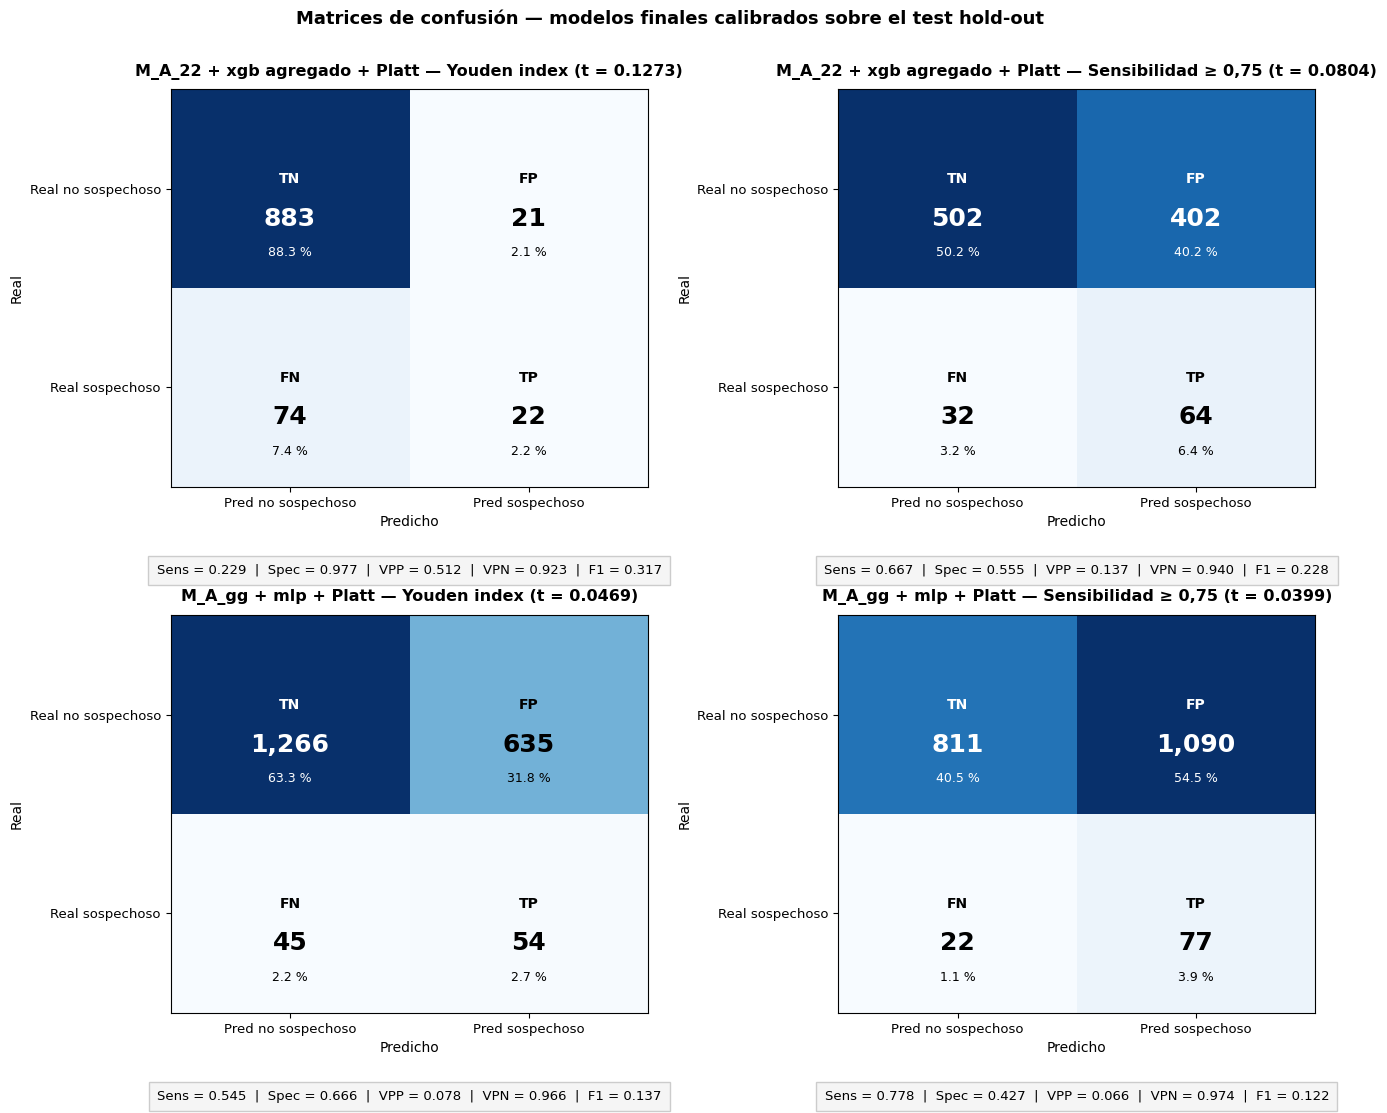

Guardado: matrices_confusion_modelo_final.png


In [ ]:
# Ilustración 20 nueva — 4 matrices de confusión (2 modelos × 2 umbrales) ──
fig, axes = plt.subplots(2, 2, figsize=(13.5, 11))

# Orden fijo: columna izq = Youden, columna der = sens≥0.75
orden = [
    ('triaje_youden',  axes[0][0]),
    ('triaje_sens85',  axes[0][1]),
    ('loc_youden',     axes[1][0]),
    ('loc_sens85',     axes[1][1]),
]

for key, ax in orden:
    r = resultados[key]
    cm = r['cm']
    modelo_corto = 'M_A_22 + xgb agregado + Platt' if 'triaje' in key else 'M_A_gg + mlp + Platt'
    n_total = cm.sum()

    im = ax.imshow(cm, cmap='Blues', aspect='auto', interpolation='nearest')

    # Anotaciones dentro de cada celda
    labels_matriz = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            v = cm[i, j]
            pct = 100 * v / n_total if n_total > 0 else 0
            color = 'white' if v > cm.max() * 0.55 else 'black'
            ax.text(j, i - 0.05, labels_matriz[i][j], ha='center', va='center',
                    fontsize=10, color=color, fontweight='bold')
            ax.text(j, i + 0.15, f'{v:,}', ha='center', va='center',
                    fontsize=18, color=color, fontweight='bold')
            ax.text(j, i + 0.32, f'{pct:.1f} %', ha='center', va='center',
                    fontsize=9, color=color)

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred no sospechoso', 'Pred sospechoso'], fontsize=9.5)
    ax.set_yticklabels(['Real no sospechoso', 'Real sospechoso'], fontsize=9.5)
    ax.set_ylabel('Real', fontsize=10)
    ax.set_xlabel('Predicho', fontsize=10)

    # Título con modelo y umbral
    ax.set_title(f'{modelo_corto} — {r["umbral_tipo"]} (t = {r["umbral"]:.4f})',
                 fontsize=11.5, fontweight='bold', pad=10)

    # Subtítulo con métricas
    metricas_txt = (f'Sens = {r["sens"]:.3f}  |  Spec = {r["spec"]:.3f}  |  '
                    f'VPP = {r["ppv"]:.3f}  |  VPN = {r["npv"]:.3f}  |  F1 = {r["f1"]:.3f}')
    ax.text(0.5, -0.22, metricas_txt, transform=ax.transAxes, ha='center', fontsize=9.5,
            bbox=dict(facecolor='#f5f5f5', edgecolor='#cccccc', pad=6))

fig.suptitle('Matrices de confusión — modelos finales calibrados sobre el test hold-out',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(PRED_DIR_V2, 'matrices_confusion_modelo_final.png'),
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Guardado: matrices_confusion_modelo_final.png')

## 7. Análisis post-hoc: agregar M→E

Para cada modelo a nivel mama, calculamos su predicción agregada a nivel estudio tomando `max(pred_L, pred_R)`. Comparamos con el mismo modelo entrenado directamente a nivel estudio.

**Pregunta**: ¿es mejor predecir por mama y agregar al estudio, o predecir directamente a nivel estudio?

In [19]:
post_hoc_rows = []
for _, r in df_eval[df_eval.level == 'mama'].iterrows():
    cfg_m, head, auc_m = r['config'], r['head'], r['auc']
    # Cargar predicciones a nivel mama (test)
    _, pred_m_test = load_predictions(cfg_m, head)
    # Agregar a estudio con max
    pred_e_agg, _ = aggregate_breast_to_study(pred_m_test, study_ids_E_test, agg='max')
    auc_e_agg = roc_auc_score(y_E_test, pred_e_agg)
    
    # Comparar con E_A_{pool}_{head} (configuración análoga a nivel estudio)
    parts = cfg_m.split('_')
    pool = parts[-1]
    inp  = parts[1]    # A o AB
    cfg_e_direct = f'E_{inp}_{pool}'
    direct_row = df_eval[(df_eval['config'] == cfg_e_direct) & (df_eval['head'] == head)]
    if len(direct_row) == 0:
        auc_e_direct = np.nan; pval = np.nan
    else:
        _, pred_e_direct = load_predictions(cfg_e_direct, head)
        auc_e_direct = roc_auc_score(y_E_test, pred_e_direct)
        res = delong_test(y_E_test, pred_e_agg, pred_e_direct)
        pval = res['p_value']
    
    post_hoc_rows.append({
        'config_mama': cfg_m, 'head': head,
        'auc_mama': auc_m,
        'auc_estudio_agg_max': auc_e_agg,
        'config_estudio_directo': cfg_e_direct,
        'auc_estudio_directo': auc_e_direct,
        'delta_agg_minus_directo': auc_e_agg - auc_e_direct if not np.isnan(auc_e_direct) else np.nan,
        'p_delong': pval,
    })

df_post_hoc = pd.DataFrame(post_hoc_rows).sort_values('auc_estudio_agg_max', ascending=False)
df_post_hoc.to_csv(os.path.join(PRED_DIR_V2, 'post_hoc_mama_to_estudio.csv'), index=False)
print('Top 10 — Mama agregada vs Estudio directo:')
print(df_post_hoc.head(10).to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else x))

Top 10 — Mama agregada vs Estudio directo:
config_mama      head  auc_mama  auc_estudio_agg_max config_estudio_directo  auc_estudio_directo  delta_agg_minus_directo  p_delong
     M_A_22       xgb    0.6813               0.6891                 E_A_22               0.6315                   0.0576    0.0552
    M_AB_gg      lgbm    0.6758               0.6721                E_AB_gg               0.6283                   0.0438    0.1553
     M_A_22        rf    0.6803               0.6679                 E_A_22               0.6374                   0.0305    0.1208
    M_AB_gg    histgb    0.6811               0.6628                E_AB_gg               0.6393                   0.0235    0.3385
     M_A_22    histgb    0.6653               0.6571                 E_A_22               0.6347                   0.0224    0.4823
     M_A_gg       mlp    0.6866               0.6553                 E_A_gg               0.6237                   0.0315    0.1742
     M_A_22      lgbm    0.6415  

## 8. Curvas ROC y PR — top 5 configuraciones

Visualización comparativa de las mejores configuraciones por nivel.

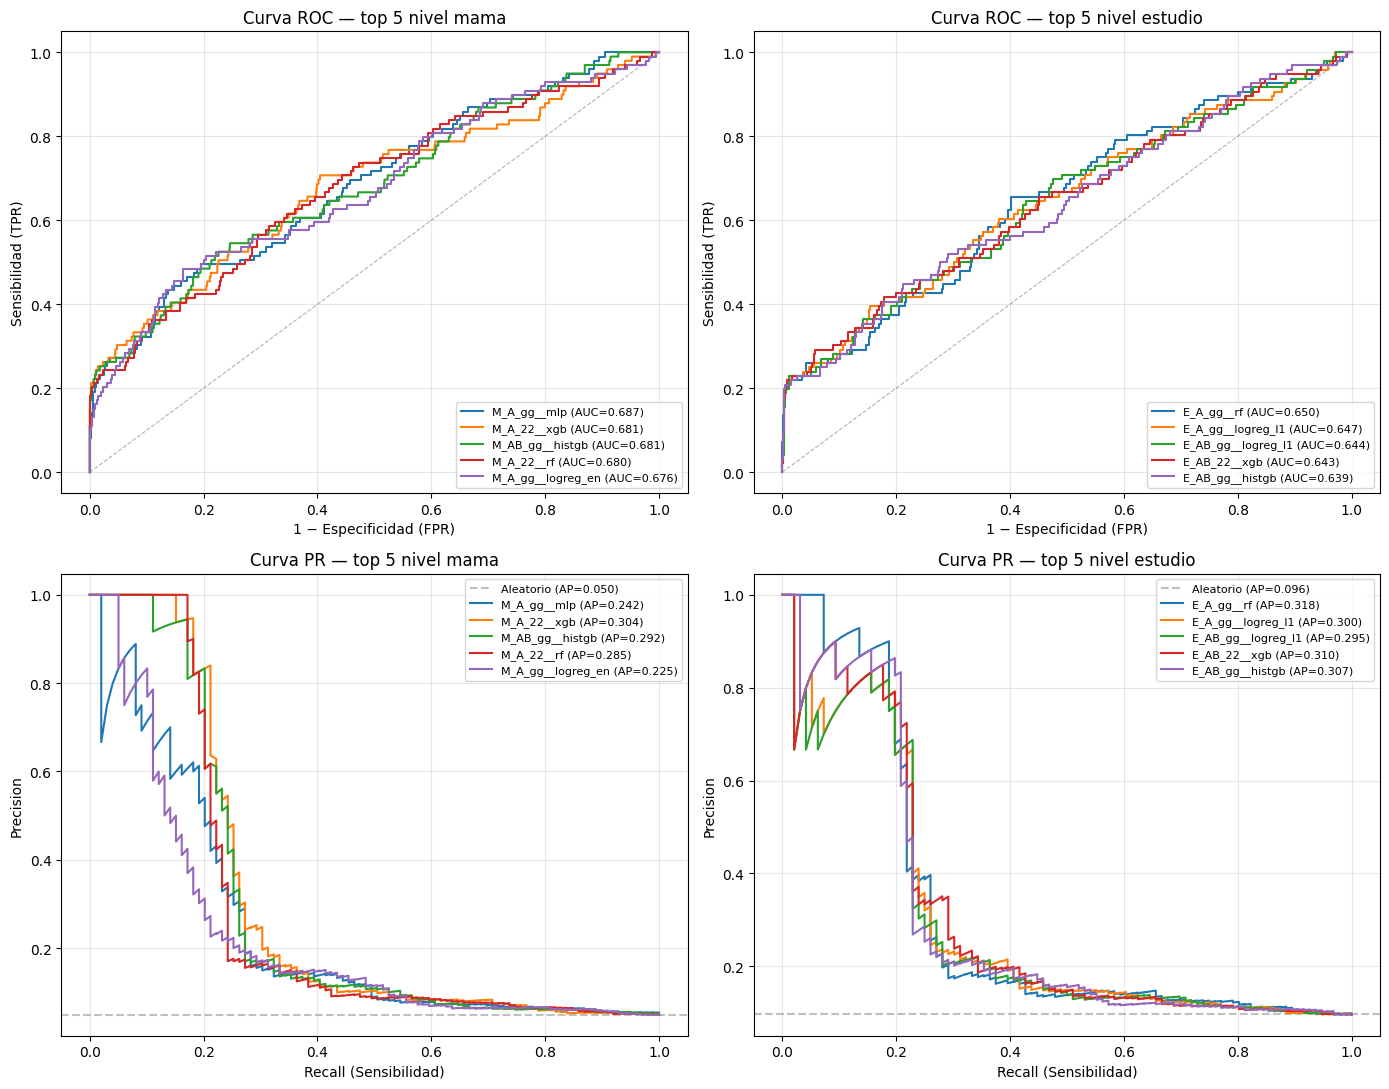

Guardado: curvas_top.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for col, level in enumerate(['mama', 'estudio']):
    top5 = df_eval[df_eval.level == level].nlargest(5, 'auc')
    y_test = y_M_test if level == 'mama' else y_E_test
    
    # ROC
    ax = axes[0, col]
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=0.8)
    for _, r in top5.iterrows():
        _, pred = load_predictions(r['config'], r['head'])
        fpr, tpr, _ = roc_curve(y_test, pred)
        ax.plot(fpr, tpr, label=f'{r["config"]}__{r["head"]} (AUC={r["auc"]:.3f})', linewidth=1.5)
    ax.set_xlabel('1 − Especificidad (FPR)')
    ax.set_ylabel('Sensibilidad (TPR)')
    ax.set_title(f'Curva ROC — top 5 nivel {level}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    
    # PR
    ax = axes[1, col]
    prevalencia = y_test.mean()
    ax.axhline(prevalencia, color='gray', linestyle='--', alpha=0.5, label=f'Aleatorio (AP={prevalencia:.3f})')
    for _, r in top5.iterrows():
        _, pred = load_predictions(r['config'], r['head'])
        prec, rec, _ = precision_recall_curve(y_test, pred)
        ax.plot(rec, prec, label=f'{r["config"]}__{r["head"]} (AP={r["ap"]:.3f})', linewidth=1.5)
    ax.set_xlabel('Recall (Sensibilidad)')
    ax.set_ylabel('Precision')
    ax.set_title(f'Curva PR — top 5 nivel {level}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PRED_DIR_V2, 'curvas_top.png'), dpi=140, bbox_inches='tight')
plt.show()
print(f'Guardado: curvas_top.png')

## 9. Resumen ejecutivo final

Esta celda imprime un resumen consolidado para usarlo directamente en la redacción del capítulo 5 de la memoria.

In [21]:
print('═' * 75)
print(' RESUMEN EJECUTIVO — NB10 evaluación')
print('═' * 75)

print('\n1. MEJORES CONFIGURACIONES (test AUC + IC95%)')
for level in ['mama', 'estudio']:
    top3 = df_eval[df_eval.level == level].nlargest(3, 'auc')
    print(f'\n  Nivel {level}:')
    for _, r in top3.iterrows():
        print(f'    {r["config"]:14s} {r["head"]:12s}  '
              f'AUC={r["auc"]:.4f} [{r["auc_lo"]:.4f}, {r["auc_hi"]:.4f}]   '
              f'AP={r["ap"]:.4f}   Brier={r["brier"]:.4f}   ECE={r["ece"]:.4f}')

print('\n2. HALLAZGOS METODOLÓGICOS (DeLong)')
for tipo in df_delong['tipo'].unique():
    sub = df_delong[df_delong['tipo'] == tipo]
    sig = sub[sub['significativo_005']]
    delta_mean = sub['delta'].mean()
    sign = 'primero gana' if delta_mean > 0 else 'segundo gana'
    print(f'  {tipo:20s}: {len(sig)}/{len(sub)} significativos  Δ medio = {delta_mean:+.4f} ({sign} en promedio)')

print('\n3. COMPARACIÓN CONTRA HITO 2')
if len(df_h2_vs_v2) > 0:
    for _, r in df_h2_vs_v2.iterrows():
        sig = '★' if r['p_value'] < 0.05 else ' '
        print(f'  {sig}  {r["v2_best"]:25s} vs {r["hito2_run"]:20s}  '
              f'Δ={r["delta_v2_minus_hito2"]:+.4f}  p={r["p_value"]:.4f}')
else:
    print('  (no se pudieron cargar predicciones del Hito 2)')

print('\n4. CALIBRACIÓN DEL TOP NIVEL MAMA')
best_mama = df_eval[df_eval.level == 'mama'].nlargest(1, 'auc').iloc[0]
print(f'   {best_mama["config"]}__{best_mama["head"]}: Brier={best_mama["brier"]:.4f}  ECE={best_mama["ece"]:.4f}')
print('   (Si Brier > 0.15 o ECE > 0.1, el NB12 de calibración Platt/isotónica mejorará estos números)')

print('\n' + '═' * 75)
print(' Archivos generados:')
print('═' * 75)
for f in ['eval_completo_v2.csv', 'delong_pareado_v2.csv', 'eval_densidad_v2.csv',
         'post_hoc_mama_to_estudio.csv', 'curvas_top.png']:
    path = os.path.join(PRED_DIR_V2, f)
    exists = '✓' if os.path.isfile(path) else '✗'
    print(f'  {exists}  {f}')

═══════════════════════════════════════════════════════════════════════════
 RESUMEN EJECUTIVO — NB10 evaluación
═══════════════════════════════════════════════════════════════════════════

1. MEJORES CONFIGURACIONES (test AUC + IC95%)

  Nivel mama:
    M_A_gg         mlp           AUC=0.6866 [0.6289, 0.7417]   AP=0.2422   Brier=0.1943   ECE=0.3811
    M_A_22         xgb           AUC=0.6813 [0.6181, 0.7440]   AP=0.3036   Brier=0.1175   ECE=0.2755
    M_AB_gg        histgb        AUC=0.6811 [0.6189, 0.7412]   AP=0.2915   Brier=0.0649   ECE=0.1468

  Nivel estudio:
    E_A_gg         rf            AUC=0.6499 [0.5879, 0.7119]   AP=0.3178   Brier=0.0753   ECE=0.0206
    E_A_gg         logreg_l1     AUC=0.6465 [0.5759, 0.7111]   AP=0.3002   Brier=0.2163   ECE=0.3560
    E_AB_gg        logreg_l1     AUC=0.6437 [0.5750, 0.7059]   AP=0.2950   Brier=0.2228   ECE=0.3667

2. HALLAZGOS METODOLÓGICOS (DeLong)
  pool_2x2_vs_gg      : 4/42 significativos  Δ medio = -0.0169 (segundo gana en promedio

## Siguientes pasos

- **NB11 — Fusión con densidad** sobre la mejor configuración (`M_A_gg + mlp` según los resultados actuales). Replica el experimento del NB07 del Hito 2 pero sobre la mejor combinación encontrada en el NB09, bajo el mismo protocolo unificado.
- **NB12 — Calibración post-hoc** (Platt e isotónica) sobre el mejor MLP a nivel mama. Reduce Brier y ECE sin tocar AUC.
- Tras NB11 y NB12, el experimental está completo y se procede a la **redacción definitiva** de los capítulos 4 (Metodología), 5 (Resultados) y 6 (Conclusiones) de la memoria.